In [ ]:
# ============================================================
# EXP-001 — NEOWISE First Light Curve
# ============================================================

!pip -q install pyarrow astropy pandas matplotlib numpy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from astropy.coordinates import SkyCoord
import astropy.units as u

# ------------------------------------------------------------
# 1. Experiment configuration
# ------------------------------------------------------------

RA_CENTER = 180.0       # degrees
DEC_CENTER = 0.0        # degrees
RADIUS_DEG = 0.10       # tiny sky region

DATA_ROOT = (
    "s3://nasa-irsa-wise/wise/neowiser/"
    "catalogs/p1bs_psd/healpix_k5/"
)

print("Experiment configuration ready.")

Experiment configuration ready.


In [ ]:

import pyarrow
import pyarrow.fs
import pyarrow.dataset as ds

bucket = "nasa-irsa-wise"
base_prefix = "wise/neowiser/catalogs/p1bs_psd/healpix_k5"

# Start with ONE year for EXP-001.
year = "year11"

metadata_path = (
    f"{bucket}/{base_prefix}/{year}/"
    f"neowiser-healpix_k5-{year}.parquet/_metadata"
)

fs = pyarrow.fs.S3FileSystem(
    region="us-west-2",
    anonymous=True
)

neowise_ds = ds.parquet_dataset(
    metadata_path,
    filesystem=fs,
    partitioning="hive"
)

print("Dataset opened successfully.")
print(neowise_ds.schema)

Dataset opened successfully.
source_id: string not null
  -- field metadata --
  units: ''
  description: 'Unique source identifier. Source_id has the general form ' + 183
frame_num: int64 not null
  -- field metadata --
  units: ''
  description: 'Number of the frameset on which this source was extracted' + 1087
scan_id: string not null
  -- field metadata --
  units: ''
  description: 'Scan identifier. This is a six-character string that iden' + 1617
src: int64 not null
  -- field metadata --
  units: ''
  description: 'Sequential number of this source in the Single-Exposure f' + 93
ra: double not null
  -- field metadata --
  units: 'deg'
  description: 'J2000 right ascension with respect to 2MASS PSC reference' + 66
dec: double not null
  -- field metadata --
  units: 'deg'
  description: 'J2000 declination with respect to 2MASS PSC reference sou' + 62
sigra: double
  -- field metadata --
  units: 'arcsec'
  description: 'One-sigma uncertainty in right ascension coordinate.'
sigdec

In [ ]:
# ============================================================
# EXP-001 — Inspect NEOWISE schema
# ============================================================

schema_names = [field.name for field in neowise_ds.schema]

print(f"Total columns: {len(schema_names)}")
print()

for i, name in enumerate(schema_names):
    print(f"{i:3d}  {name}")

Total columns: 145

  0  source_id
  1  frame_num
  2  scan_id
  3  src
  4  ra
  5  dec
  6  sigra
  7  sigdec
  8  sigradec
  9  glon
 10  glat
 11  elon
 12  elat
 13  w1x
 14  w1y
 15  w2x
 16  w2y
 17  w1sky
 18  w1sigsk
 19  w1conf
 20  w2sky
 21  w2sigsk
 22  w2conf
 23  w1fitr
 24  w2fitr
 25  w1snr
 26  w2snr
 27  w1flux
 28  w1sigflux
 29  w2flux
 30  w2sigflux
 31  w1mpro
 32  w1sigmpro
 33  w1rchi2
 34  w2mpro
 35  w2sigmpro
 36  w2rchi2
 37  rchi2
 38  nb
 39  na
 40  w1frtr
 41  w2frtr
 42  w1sat
 43  w2sat
 44  satnum
 45  w1mag
 46  w1sigm
 47  w1flg
 48  w1mcor
 49  w2mag
 50  w2sigm
 51  w2flg
 52  w2mcor
 53  w1mag_1
 54  w1sigm_1
 55  w1flg_1
 56  w2mag_1
 57  w2sigm_1
 58  w2flg_1
 59  w1mag_2
 60  w1sigm_2
 61  w1flg_2
 62  w2mag_2
 63  w2sigm_2
 64  w2flg_2
 65  w1mag_3
 66  w1sigm_3
 67  w1flg_3
 68  w2mag_3
 69  w2sigm_3
 70  w2flg_3
 71  w1mag_4
 72  w1sigm_4
 73  w1flg_4
 74  w2mag_4
 75  w2sigm_4
 76  w2flg_4
 77  w1mag_5
 78  w1sigm_5
 79  w1flg_5
 80  w2ma

In [ ]:
# Search for columns relevant to our first experiment

keywords = [
    "ra", "dec", "mjd", "time",
    "w1", "w2",
    "sig", "err",
    "qual", "flag"
]

print("Potentially useful columns:\n")

for name in schema_names:
    if any(k in name.lower() for k in keywords):
        print(name)

Potentially useful columns:

frame_num
ra
dec
sigra
sigdec
sigradec
w1x
w1y
w2x
w2y
w1sky
w1sigsk
w1conf
w2sky
w2sigsk
w2conf
w1fitr
w2fitr
w1snr
w2snr
w1flux
w1sigflux
w2flux
w2sigflux
w1mpro
w1sigmpro
w1rchi2
w2mpro
w2sigmpro
w2rchi2
w1frtr
w2frtr
w1sat
w2sat
w1mag
w1sigm
w1flg
w1mcor
w2mag
w2sigm
w2flg
w2mcor
w1mag_1
w1sigm_1
w1flg_1
w2mag_1
w2sigm_1
w2flg_1
w1mag_2
w1sigm_2
w1flg_2
w2mag_2
w2sigm_2
w2flg_2
w1mag_3
w1sigm_3
w1flg_3
w2mag_3
w2sigm_3
w2flg_3
w1mag_4
w1sigm_4
w1flg_4
w2mag_4
w2sigm_4
w2flg_4
w1mag_5
w1sigm_5
w1flg_5
w2mag_5
w2sigm_5
w2flg_5
w1mag_6
w1sigm_6
w1flg_6
w2mag_6
w2sigm_6
w2flg_6
w1mag_7
w1sigm_7
w1flg_7
w2mag_7
w2sigm_7
w2flg_7
w1mag_8
w1sigm_8
w1flg_8
w2mag_8
w2sigm_8
w2flg_8
w1cc_map
w1cc_map_str
w2cc_map
w2cc_map_str
cc_flags
qual_frame
ph_qual
j_msig_2mass
h_msig_2mass
k_msig_2mass
w1mpro_allwise
w1sigmpro_allwise
w2mpro_allwise
w2sigmpro_allwise
w3sigmpro_allwise
w4sigmpro_allwise
mjd


In [ ]:
# ============================================================
# EXP-001 — Extract a small NEOWISE sky region
# ============================================================

from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import pandas as pd

# Small test region
RA_CENTER = 180.0
DEC_CENTER = 0.0
RADIUS_DEG = 0.10

# Columns needed for EXP-001
columns = [
    "ra",
    "dec",
    "mjd",
    "w1mpro",
    "w1sigmpro",
    "w2mpro",
    "w2sigmpro",
    "w1snr",
    "w2snr",
    "qual_frame",
    "ph_qual",
    "cc_flags",
]

# ------------------------------------------------------------
# Rough bounding-box filter first
# ------------------------------------------------------------

ra_min = RA_CENTER - RADIUS_DEG
ra_max = RA_CENTER + RADIUS_DEG
dec_min = DEC_CENTER - RADIUS_DEG
dec_max = DEC_CENTER + RADIUS_DEG

filter_expr = (
    (ds.field("ra") >= ra_min)
    & (ds.field("ra") <= ra_max)
    & (ds.field("dec") >= dec_min)
    & (ds.field("dec") <= dec_max)
)

print("Querying small sky region...")
print(f"RA  : {RA_CENTER} ± {RADIUS_DEG}°")
print(f"Dec : {DEC_CENTER} ± {RADIUS_DEG}°")

table = neowise_ds.to_table(
    columns=columns,
    filter=filter_expr
)

df = table.to_pandas()

print()
print(f"Retrieved detections: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print()
print(df.head())

Querying small sky region...
RA  : 180.0 ± 0.1°
Dec : 0.0 ± 0.1°

Retrieved detections: 8,652
Columns: 12

           ra       dec           mjd  w1mpro  w1sigmpro  w2mpro  w2sigmpro  \
0  179.940815 -0.077753  60299.662062  14.849      0.102  14.806      0.310   
1  179.962867 -0.034410  60299.662062  14.751      0.088  15.207      0.489   
2  179.973560 -0.042534  60299.662062  14.852      0.093  14.809      0.510   
3  179.936654 -0.079529  60299.662062  15.149      0.122  14.534        NaN   
4  179.910033 -0.093667  60299.662062  15.475      0.161  14.971        NaN   

   w1snr  w2snr  qual_frame ph_qual cc_flags  
0   10.6    3.5           5      AB     0000  
1   12.3    2.2           5      AC     0000  
2   11.6    2.1           5      AC     0000  
3    8.9    1.3           5      BU     0000  
4    6.7    0.9           5      BU     0000  


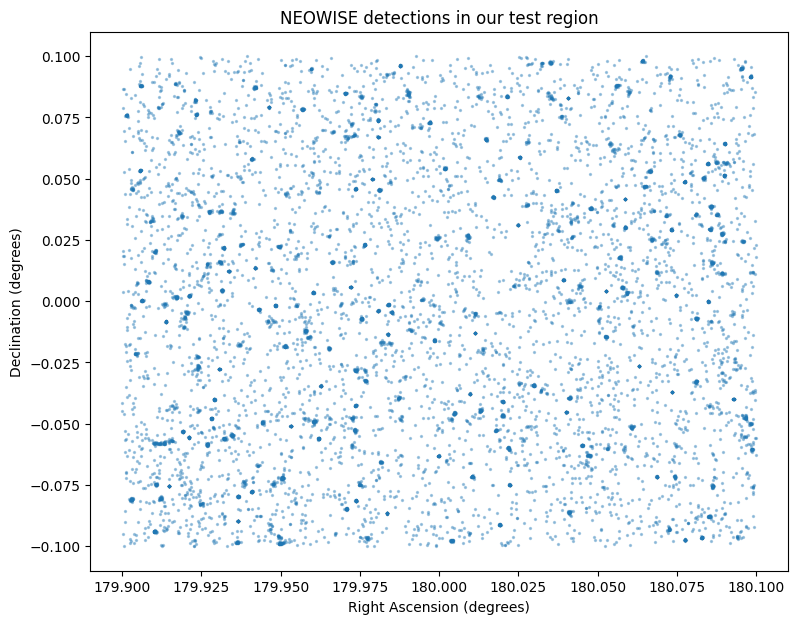

In [ ]:
# ============================================================
# EXP-001 — First look at the extracted sky region
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    df["ra"],
    df["dec"],
    s=2,
    alpha=0.35
)

ax.set_xlabel("Right Ascension (degrees)")
ax.set_ylabel("Declination (degrees)")
ax.set_title("NEOWISE detections in our test region")

plt.show()

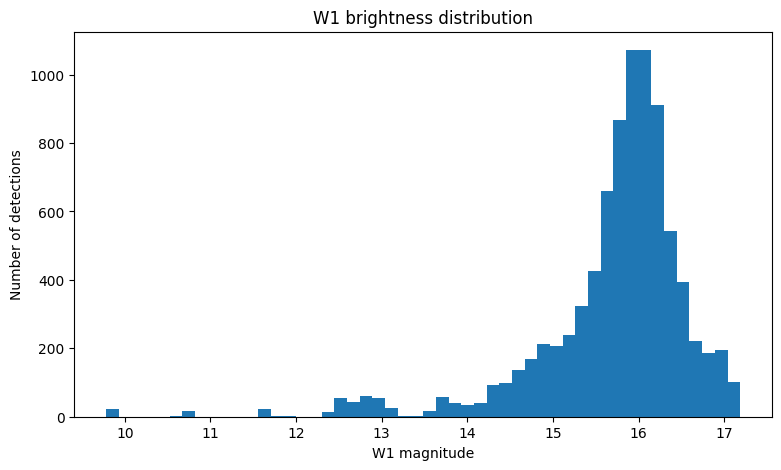

In [ ]:
# ============================================================
# Basic measurement distributions
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df["w1mpro"].dropna(),
    bins=50
)

ax.set_xlabel("W1 magnitude")
ax.set_ylabel("Number of detections")
ax.set_title("W1 brightness distribution")

plt.show()

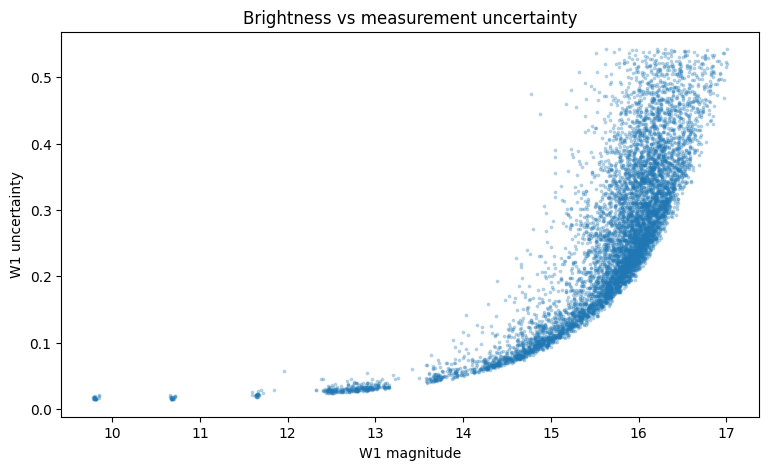

In [ ]:
# ============================================================
# Measurement uncertainty
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    df["w1mpro"],
    df["w1sigmpro"],
    s=3,
    alpha=0.25
)

ax.set_xlabel("W1 magnitude")
ax.set_ylabel("W1 uncertainty")
ax.set_title("Brightness vs measurement uncertainty")

plt.show()

In [ ]:
# ============================================================
# EXP-001 — Build approximate star groups
# ============================================================

# Work only with measurements that have usable positions
work = df[
    df["ra"].notna() &
    df["dec"].notna() &
    df["w1mpro"].notna()
].copy()

# Round sky coordinates to create small spatial cells.
# This is NOT our final star-grouping method.
# It is only a simple experiment to understand the problem.

CELL_SIZE_DEG = 0.001

work["ra_cell"] = np.floor(work["ra"] / CELL_SIZE_DEG).astype(int)
work["dec_cell"] = np.floor(work["dec"] / CELL_SIZE_DEG).astype(int)

work["cell_id"] = (
    work["ra_cell"].astype(str)
    + "_"
    + work["dec_cell"].astype(str)
)

# Count measurements in each spatial cell
cell_counts = (
    work.groupby("cell_id")
    .size()
    .sort_values(ascending=False)
)

print(f"Usable detections: {len(work):,}")
print(f"Spatial cells containing detections: {len(cell_counts):,}")
print()
print("Most populated cells:")
print(cell_counts.head(20))

Usable detections: 8,644
Spatial cells containing detections: 4,653

Most populated cells:
cell_id
179936_-90    33
179936_-80    32
179914_-76    31
179973_-82    29
179983_-87    28
179970_-85    27
179962_-35    26
180022_-75    25
179921_-56    25
180077_-98    25
180068_-72    25
179930_-28    25
179940_-78    25
179973_-43    24
179913_-9     24
179960_3      24
179928_-48    24
179948_-2     24
179983_-14    24
179919_-54    24
dtype: int64


In [ ]:
# ============================================================
# EXP-001 — Inspect the most populated spatial cell
# ============================================================

top_cell = cell_counts.index[0]

cell_data = work[work["cell_id"] == top_cell].copy()

print("Cell:", top_cell)
print("Number of detections:", len(cell_data))
print()

print(
    cell_data[
        [
            "ra",
            "dec",
            "mjd",
            "w1mpro",
            "w1sigmpro",
            "w1snr",
            "w2mpro",
            "w2sigmpro",
            "w2snr"
        ]
    ].sort_values("mjd").to_string(index=False)
)

Cell: 179936_-90
Number of detections: 33

        ra       dec          mjd  w1mpro  w1sigmpro  w1snr  w2mpro  w2sigmpro  w2snr
179.936514 -0.089686 60299.662062  12.479      0.030   36.5  12.505      0.058   18.7
179.936478 -0.089722 60299.662190  12.664      0.031   34.5  12.702      0.057   19.0
179.936502 -0.089764 60299.791183  12.563      0.026   41.5  12.672      0.061   17.8
179.936410 -0.089756 60299.791311  12.603      0.028   38.5  12.617      0.054   20.1
179.936486 -0.089729 60299.920304  12.532      0.026   41.4  12.598      0.054   20.3
179.936419 -0.089732 60299.920431  12.536      0.028   38.4  12.610      0.058   18.7
179.936486 -0.089789 60300.049425  12.566      0.028   38.2  12.633      0.054   20.1
179.936507 -0.089759 60300.049552  12.533      0.030   36.5  12.611      0.056   19.3
179.936477 -0.089744 60300.113985  12.495      0.028   38.4  12.529      0.050   21.6
179.936490 -0.089742 60300.114113  12.552      0.030   36.7  12.566      0.059   18.4
179.936458 

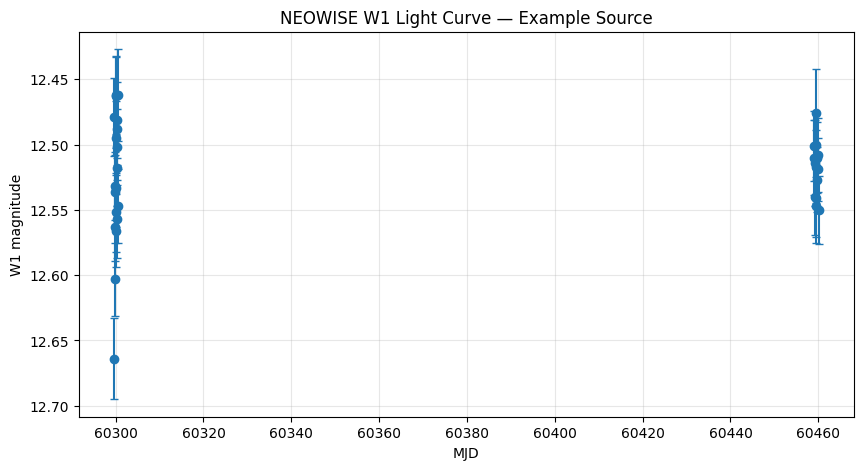

In [ ]:
# ============================================================
# EXP-001 — First Light Curve
# ============================================================

import matplotlib.pyplot as plt

lc = cell_data.sort_values("mjd").copy()

plt.figure(figsize=(10, 5))

plt.errorbar(
    lc["mjd"],
    lc["w1mpro"],
    yerr=lc["w1sigmpro"],
    fmt="o",
    capsize=3
)

plt.gca().invert_yaxis()

plt.xlabel("MJD")
plt.ylabel("W1 magnitude")
plt.title("NEOWISE W1 Light Curve — Example Source")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# EXP-001 — Recreate the light curve for the selected source
# ============================================================

top_cell = cell_counts.index[0]

lc = (
    work[work["cell_id"] == top_cell]
    .copy()
    .sort_values("mjd")
)

print("Cell:", top_cell)
print("Number of observations:", len(lc))
print()

print(
    lc[
        [
            "mjd",
            "w1mpro",
            "w1sigmpro",
            "w1snr",
            "w2mpro",
            "w2sigmpro",
            "w2snr",
        ]
    ].to_string(index=False)
)

Cell: 179936_-90
Number of observations: 33

         mjd  w1mpro  w1sigmpro  w1snr  w2mpro  w2sigmpro  w2snr
60299.662062  12.479      0.030   36.5  12.505      0.058   18.7
60299.662190  12.664      0.031   34.5  12.702      0.057   19.0
60299.791183  12.563      0.026   41.5  12.672      0.061   17.8
60299.791311  12.603      0.028   38.5  12.617      0.054   20.1
60299.920304  12.532      0.026   41.4  12.598      0.054   20.3
60299.920431  12.536      0.028   38.4  12.610      0.058   18.7
60300.049425  12.566      0.028   38.2  12.633      0.054   20.1
60300.049552  12.533      0.030   36.5  12.611      0.056   19.3
60300.113985  12.495      0.028   38.4  12.529      0.050   21.6
60300.114113  12.552      0.030   36.7  12.566      0.059   18.4
60300.178546  12.463      0.030   36.2  12.494      0.060   18.2
60300.178673  12.462      0.030   36.1  12.497      0.053   20.3
60300.243106  12.481      0.029   37.9  12.629      0.056   19.4
60300.243233  12.518      0.029   37.8  12.55

In [ ]:
# ============================================================
# EXP-001 — Uncertainty-aware variability
# ============================================================

w1 = lc["w1mpro"].dropna()
w1_err = lc.loc[w1.index, "w1sigmpro"]

# Observed scatter
observed_std = w1.std()

# Typical reported measurement uncertainty
typical_error = np.sqrt(np.mean(w1_err**2))

# Excess scatter:
# how much scatter remains after accounting for measurement error
excess_variance = observed_std**2 - typical_error**2
excess_scatter = np.sqrt(max(0, excess_variance))

print(f"Observed W1 scatter       : {observed_std:.4f} mag")
print(f"Typical measurement error : {typical_error:.4f} mag")
print(f"Excess scatter             : {excess_scatter:.4f} mag")

Observed W1 scatter       : 0.0417 mag
Typical measurement error : 0.0288 mag
Excess scatter             : 0.0302 mag


========== POSITION STABILITY ==========
Median RA               : 179.93646500 deg
Median Dec              : -0.08974750 deg
Median position offset : 0.1324 arcsec
Maximum position offset: 0.2933 arcsec

========== UNUSUAL OBSERVATIONS ==========
         mjd         ra       dec  w1mpro  w1sigmpro  w1snr  w2mpro  w2sigmpro  w2snr  w1_deviation_sigma
60299.662190 179.936478 -0.089722  12.664      0.031   34.5  12.702      0.057   19.0            4.513496
60299.791311 179.936410 -0.089756  12.603      0.028   38.5  12.617      0.054   20.1            2.818513
60300.178546 179.936458 -0.089751  12.463      0.030   36.2  12.494      0.060   18.2           -2.036054
60300.178673 179.936384 -0.089756  12.462      0.030   36.1  12.497      0.053   20.3           -2.069388

========== POSITION COMPARISON ==========
Normal median offset  : 0.1324 arcsec
Unusual median offset : 0.1511 arcsec
Unusual maximum offset: 0.2933 arcsec

========== OBSERVATION TIMING ==========
         mjd  time_gap_

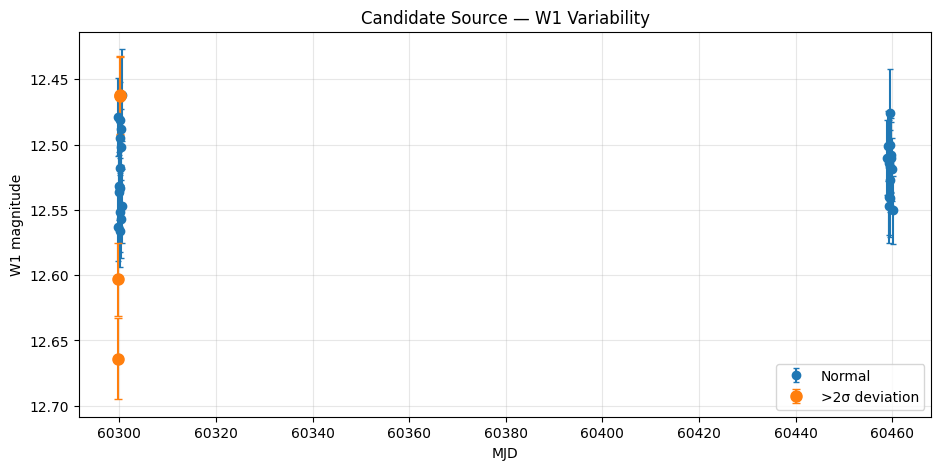

In [ ]:
# ============================================================
# EXP-001 — Candidate Artifact / Observation Checks
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Start from the light-curve dataframe
check = lc.copy()

# ------------------------------------------------------------
# 1. POSITION STABILITY
# ------------------------------------------------------------

ra_center = check["ra"].median()
dec_center = check["dec"].median()

# Convert positional differences from degrees to arcseconds
check["ra_offset_arcsec"] = (
    (check["ra"] - ra_center) * 3600
)

check["dec_offset_arcsec"] = (
    (check["dec"] - dec_center) * 3600
)

check["position_offset_arcsec"] = np.sqrt(
    check["ra_offset_arcsec"]**2 +
    check["dec_offset_arcsec"]**2
)

print("========== POSITION STABILITY ==========")
print(f"Median RA               : {ra_center:.8f} deg")
print(f"Median Dec              : {dec_center:.8f} deg")
print(
    f"Median position offset : "
    f"{check['position_offset_arcsec'].median():.4f} arcsec"
)
print(
    f"Maximum position offset: "
    f"{check['position_offset_arcsec'].max():.4f} arcsec"
)


# ------------------------------------------------------------
# 2. IDENTIFY UNUSUAL W1 MEASUREMENTS
# ------------------------------------------------------------

weighted_mean_w1 = np.average(
    check["w1mpro"],
    weights=1 / check["w1sigmpro"]**2
)

check["w1_deviation_sigma"] = (
    (check["w1mpro"] - weighted_mean_w1)
    / check["w1sigmpro"]
)

check["unusual"] = (
    check["w1_deviation_sigma"].abs() >= 2
)

print("\n========== UNUSUAL OBSERVATIONS ==========")

print(
    check.loc[
        check["unusual"],
        [
            "mjd",
            "ra",
            "dec",
            "w1mpro",
            "w1sigmpro",
            "w1snr",
            "w2mpro",
            "w2sigmpro",
            "w2snr",
            "w1_deviation_sigma"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 3. POSITION: NORMAL VS UNUSUAL
# ------------------------------------------------------------

normal = check.loc[
    ~check["unusual"],
    "position_offset_arcsec"
]

unusual = check.loc[
    check["unusual"],
    "position_offset_arcsec"
]

print("\n========== POSITION COMPARISON ==========")

print(
    f"Normal median offset  : "
    f"{normal.median():.4f} arcsec"
)

print(
    f"Unusual median offset : "
    f"{unusual.median():.4f} arcsec"
)

print(
    f"Unusual maximum offset: "
    f"{unusual.max():.4f} arcsec"
)


# ------------------------------------------------------------
# 4. OBSERVATION TIMING
# ------------------------------------------------------------

check = check.sort_values("mjd").reset_index(drop=True)

check["time_gap_days"] = check["mjd"].diff()

print("\n========== OBSERVATION TIMING ==========")

print(
    check[
        [
            "mjd",
            "time_gap_days",
            "w1mpro",
            "w1_deviation_sigma",
            "unusual"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 5. LIGHT CURVE WITH UNUSUAL POINTS
# ------------------------------------------------------------

plt.figure(figsize=(11, 5))

normal_points = check[~check["unusual"]]
unusual_points = check[check["unusual"]]

plt.errorbar(
    normal_points["mjd"],
    normal_points["w1mpro"],
    yerr=normal_points["w1sigmpro"],
    fmt="o",
    capsize=2,
    label="Normal"
)

if len(unusual_points) > 0:
    plt.errorbar(
        unusual_points["mjd"],
        unusual_points["w1mpro"],
        yerr=unusual_points["w1sigmpro"],
        fmt="o",
        markersize=8,
        capsize=3,
        label=">2σ deviation"
    )

plt.gca().invert_yaxis()

plt.xlabel("MJD")
plt.ylabel("W1 magnitude")
plt.title("Candidate Source — W1 Variability")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# EXP-001 — Observation Cadence Check
# ============================================================

cadence = check.sort_values("mjd").copy()

# Convert time gaps from days to minutes
cadence["gap_minutes"] = cadence["mjd"].diff() * 24 * 60

print("========== OBSERVATION CADENCE ==========")

print(
    cadence[
        [
            "mjd",
            "gap_minutes",
            "w1mpro",
            "w1_deviation_sigma",
            "unusual"
        ]
    ].to_string(index=False)
)

print("\n========== GAP STATISTICS ==========")

valid_gaps = cadence["gap_minutes"].dropna()

print(f"Median gap : {valid_gaps.median():.2f} minutes")
print(f"Minimum gap: {valid_gaps.min():.2f} minutes")
print(f"Maximum gap: {valid_gaps.max():.2f} minutes")

print("\n========== UNUSUAL MEASUREMENTS ==========")

unusual_cadence = cadence[cadence["unusual"]].copy()

print(
    unusual_cadence[
        [
            "mjd",
            "gap_minutes",
            "w1mpro",
            "w1_deviation_sigma"
        ]
    ].to_string(index=False)
)

========== OBSERVATION CADENCE ==========
         mjd   gap_minutes  w1mpro  w1_deviation_sigma  unusual
60299.662062           NaN  12.479           -1.502721    False
60299.662190      0.183326  12.664            4.513496     True
60299.791183    185.750611  12.563            1.496860    False
60299.791311      0.183413  12.603            2.818513     True
60299.920304    185.750539  12.532            0.304553    False
60299.920431      0.183341  12.536            0.425656    False
60300.049425    185.750626  12.566            1.497085    False
60300.049552      0.183341  12.533            0.297279    False
60300.113985     92.783664  12.495           -1.038630    False
60300.114113      0.183326  12.552            0.930612    False
60300.178546     92.783549  12.463           -2.036054     True
60300.178673      0.183413  12.462           -2.069388     True
60300.243106     92.783534  12.481           -1.485573    False
60300.243233      0.183398  12.518           -0.209711    Fals

In [ ]:
# ============================================================
# EXP-001 — Close-Pair Consistency Test
# ============================================================

pair_data = check.sort_values("mjd").copy().reset_index(drop=True)

# Difference between consecutive observations
pair_data["dt_seconds"] = pair_data["mjd"].diff() * 86400

# Select close observations (~11 seconds apart)
CLOSE_PAIR_MAX_SECONDS = 20

pairs = []

for i in range(1, len(pair_data)):

    dt = pair_data.loc[i, "dt_seconds"]

    if dt <= CLOSE_PAIR_MAX_SECONDS:

        previous = pair_data.loc[i - 1]
        current = pair_data.loc[i]

        pairs.append({
            "first_mjd": previous["mjd"],
            "second_mjd": current["mjd"],
            "dt_seconds": dt,

            "first_w1": previous["w1mpro"],
            "second_w1": current["w1mpro"],
            "delta_w1": current["w1mpro"] - previous["w1mpro"],

            "first_w2": previous["w2mpro"],
            "second_w2": current["w2mpro"],
            "delta_w2": current["w2mpro"] - previous["w2mpro"],

            "first_unusual": previous["unusual"],
            "second_unusual": current["unusual"]
        })

pairs = pd.DataFrame(pairs)

print("========== CLOSE PAIRS ==========")

if len(pairs) == 0:

    print("No close observation pairs found.")

else:

    print(pairs.to_string(index=False))

    print("\n========== PAIR STATISTICS ==========")

    print(f"Number of close pairs : {len(pairs)}")

    print(
        f"Median |ΔW1|         : "
        f"{pairs['delta_w1'].abs().median():.4f} mag"
    )

    print(
        f"Maximum |ΔW1|        : "
        f"{pairs['delta_w1'].abs().max():.4f} mag"
    )

    print(
        f"Median |ΔW2|         : "
        f"{pairs['delta_w2'].abs().median():.4f} mag"
    )

    print(
        f"Maximum |ΔW2|        : "
        f"{pairs['delta_w2'].abs().max():.4f} mag"
    )

    print("\n========== UNUSUAL CLOSE PAIRS ==========")

    unusual_pairs = pairs[
        pairs["first_unusual"] |
        pairs["second_unusual"]
    ]

    if len(unusual_pairs) == 0:
        print("No close pair contains an unusual measurement.")
    else:
        print(unusual_pairs.to_string(index=False))

========== CLOSE PAIRS ==========
   first_mjd   second_mjd  dt_seconds  first_w1  second_w1  delta_w1  first_w2  second_w2  delta_w2  first_unusual  second_unusual
60299.662062 60299.662190   10.999584    12.479     12.664     0.185    12.505     12.702     0.197          False            True
60299.791183 60299.791311   11.004768    12.563     12.603     0.040    12.672     12.617    -0.055          False            True
60299.920304 60299.920431   11.000448    12.532     12.536     0.004    12.598     12.610     0.012          False           False
60300.049425 60300.049552   11.000448    12.566     12.533    -0.033    12.633     12.611    -0.022          False           False
60300.113985 60300.114113   10.999584    12.495     12.552     0.057    12.529     12.566     0.037          False           False
60300.178546 60300.178673   11.004768    12.463     12.462    -0.001    12.494     12.497     0.003           True            True
60300.243106 60300.243233   11.003904    12.481  

In [ ]:
# ============================================================
# EXP-001 — Reconstruct Candidate + Metadata Inspection
# ============================================================

import pyarrow
import pyarrow.dataset as ds
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Reopen NEOWISE Year 11 dataset
# ------------------------------------------------------------

bucket = "nasa-irsa-wise"
base_prefix = "wise/neowiser/catalogs/p1bs_psd/healpix_k5"
year = "year11"

metadata_path = (
    f"{bucket}/{base_prefix}/{year}/"
    f"neowiser-healpix_k5-{year}.parquet/_metadata"
)

fs = pyarrow.fs.S3FileSystem(
    region="us-west-2",
    anonymous=True
)

neowise_ds = ds.parquet_dataset(
    metadata_path,
    filesystem=fs,
    partitioning="hive"
)

# ------------------------------------------------------------
# 2. Retrieve the same sky region
# ------------------------------------------------------------

RA_CENTER = 180.0
DEC_CENTER = 0.0
RADIUS_DEG = 0.10

ra_min = RA_CENTER - RADIUS_DEG
ra_max = RA_CENTER + RADIUS_DEG
dec_min = DEC_CENTER - RADIUS_DEG
dec_max = DEC_CENTER + RADIUS_DEG

columns = [
    "ra",
    "dec",
    "mjd",
    "w1mpro",
    "w1sigmpro",
    "w2mpro",
    "w2sigmpro",
    "w1snr",
    "w2snr",
    "qual_frame",
    "ph_qual",
    "cc_flags"
]

table = neowise_ds.to_table(
    columns=columns,
    filter=(
        (ds.field("ra") >= ra_min) &
        (ds.field("ra") <= ra_max) &
        (ds.field("dec") >= dec_min) &
        (ds.field("dec") <= dec_max)
    )
)

data = table.to_pandas()

print("Retrieved detections:", len(data))


# ------------------------------------------------------------
# 3. Reconstruct the candidate source
# ------------------------------------------------------------
#
# Candidate position from our previous experiment:
#
# RA  ≈ 179.936465
# Dec ≈ -0.0897475
#
# We use a small angular box around that position.
# ------------------------------------------------------------

CANDIDATE_RA = 179.936465
CANDIDATE_DEC = -0.0897475

SOURCE_RADIUS_DEG = 0.00010

check = data[
    (np.abs(data["ra"] - CANDIDATE_RA) <= SOURCE_RADIUS_DEG) &
    (np.abs(data["dec"] - CANDIDATE_DEC) <= SOURCE_RADIUS_DEG)
].copy()

check = check.sort_values("mjd").reset_index(drop=True)

print("Candidate detections:", len(check))


# ------------------------------------------------------------
# 4. Recreate epoch-based variability test
# ------------------------------------------------------------

check["epoch"] = (
    check["mjd"]
    .diff()
    .fillna(0)
    .gt(30)
    .cumsum()
)

# Weighted mean W1 for each epoch

epoch_means = {}

for epoch, group in check.groupby("epoch"):

    valid = (
        group["w1mpro"].notna() &
        group["w1sigmpro"].notna() &
        (group["w1sigmpro"] > 0)
    )

    g = group.loc[valid]

    weights = 1 / (g["w1sigmpro"] ** 2)

    weighted_mean = np.sum(
        g["w1mpro"] * weights
    ) / np.sum(weights)

    epoch_means[epoch] = weighted_mean


check["epoch_mean_w1"] = check["epoch"].map(epoch_means)

check["w1_residual"] = (
    check["w1mpro"] -
    check["epoch_mean_w1"]
)

check["w1_sigma_residual"] = (
    check["w1_residual"] /
    check["w1sigmpro"]
)


# ------------------------------------------------------------
# 5. Define unusual observations
# ------------------------------------------------------------

check["unusual"] = (
    check["w1_sigma_residual"].abs() >= 2
)


# ------------------------------------------------------------
# 6. ALL AVAILABLE COLUMNS
# ------------------------------------------------------------

print("\n========== ALL AVAILABLE COLUMNS ==========")

for i, col in enumerate(check.columns):
    print(f"{i:02d}: {col}")


# ------------------------------------------------------------
# 7. UNUSUAL OBSERVATIONS
# ------------------------------------------------------------

print("\n========== UNUSUAL OBSERVATIONS ==========")

metadata_cols = [
    "mjd",
    "ra",
    "dec",
    "w1mpro",
    "w1sigmpro",
    "w1snr",
    "w2mpro",
    "w2sigmpro",
    "w2snr",
    "qual_frame",
    "ph_qual",
    "cc_flags",
    "w1_residual",
    "w1_sigma_residual"
]

available_cols = [
    c for c in metadata_cols
    if c in check.columns
]

unusual = check[check["unusual"]].copy()

print(
    unusual[
        available_cols
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 8. NORMAL OBSERVATIONS
# ------------------------------------------------------------

print("\n========== NORMAL OBSERVATIONS ==========")

normal = check[~check["unusual"]]

print(
    normal[
        available_cols
    ].describe(include="all").to_string()
)


# ------------------------------------------------------------
# 9. QUALITY DISTRIBUTIONS
# ------------------------------------------------------------

print("\n========== UNUSUAL VS NORMAL QUALITY ==========")

for col in ["qual_frame", "ph_qual", "cc_flags"]:

    if col not in check.columns:
        continue

    print(f"\n--- {col} ---")

    print("\nUNUSUAL:")
    print(
        unusual[col]
        .value_counts(dropna=False)
    )

    print("\nNORMAL:")
    print(
        normal[col]
        .value_counts(dropna=False)
    )


# ------------------------------------------------------------
# 10. DIRECT COMPARISON OF NUMERICAL FEATURES
# ------------------------------------------------------------

print("\n========== NUMERICAL COMPARISON ==========")

numeric_cols = [
    "w1sigmpro",
    "w1snr",
    "w2sigmpro",
    "w2snr",
    "qual_frame"
]

for col in numeric_cols:

    if col not in check.columns:
        continue

    print(f"\n--- {col} ---")

    print(
        f"Normal median  : "
        f"{normal[col].median():.4f}"
    )

    print(
        f"Unusual median : "
        f"{unusual[col].median():.4f}"
    )

    print(
        f"Normal mean    : "
        f"{normal[col].mean():.4f}"
    )

    print(
        f"Unusual mean   : "
        f"{unusual[col].mean():.4f}"
    )

Retrieved detections: 8652
Candidate detections: 33

========== ALL AVAILABLE COLUMNS ==========
00: ra
01: dec
02: mjd
03: w1mpro
04: w1sigmpro
05: w2mpro
06: w2sigmpro
07: w1snr
08: w2snr
09: qual_frame
10: ph_qual
11: cc_flags
12: epoch
13: epoch_mean_w1
14: w1_residual
15: w1_sigma_residual
16: unusual

========== UNUSUAL OBSERVATIONS ==========
         mjd         ra       dec  w1mpro  w1sigmpro  w1snr  w2mpro  w2sigmpro  w2snr  qual_frame ph_qual cc_flags  w1_residual  w1_sigma_residual
60299.662190 179.936478 -0.089722  12.664      0.031   34.5  12.702      0.057   19.0           5      AA     0000     0.136152           4.392005
60299.791311 179.936410 -0.089756  12.603      0.028   38.5  12.617      0.054   20.1           5      AA     0000     0.075152           2.684006
60300.178546 179.936458 -0.089751  12.463      0.030   36.2  12.494      0.060   18.2          10      AA     0000    -0.064848          -2.161595
60300.178673 179.936384 -0.089756  12.462      0.030   36.1 

In [ ]:
# ============================================================
# EXP-001 — Close-Pair Significance Test
# ============================================================

pair_data = check.sort_values("mjd").copy().reset_index(drop=True)

pair_data["dt_seconds"] = pair_data["mjd"].diff() * 86400

CLOSE_PAIR_MAX_SECONDS = 20

pairs = []

for i in range(1, len(pair_data)):

    dt = pair_data.loc[i, "dt_seconds"]

    if dt <= CLOSE_PAIR_MAX_SECONDS:

        first = pair_data.loc[i - 1]
        second = pair_data.loc[i]

        delta_w1 = (
            second["w1mpro"] -
            first["w1mpro"]
        )

        delta_w2 = (
            second["w2mpro"] -
            first["w2mpro"]
        )

        sigma_delta_w1 = np.sqrt(
            first["w1sigmpro"]**2 +
            second["w1sigmpro"]**2
        )

        sigma_delta_w2 = np.sqrt(
            first["w2sigmpro"]**2 +
            second["w2sigmpro"]**2
        )

        z_w1 = delta_w1 / sigma_delta_w1
        z_w2 = delta_w2 / sigma_delta_w2

        pairs.append({
            "first_mjd": first["mjd"],
            "second_mjd": second["mjd"],
            "dt_seconds": dt,

            "delta_w1": delta_w1,
            "sigma_delta_w1": sigma_delta_w1,
            "z_w1": z_w1,

            "delta_w2": delta_w2,
            "sigma_delta_w2": sigma_delta_w2,
            "z_w2": z_w2,

            "first_unusual": first["unusual"],
            "second_unusual": second["unusual"]
        })


pairs = pd.DataFrame(pairs)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("========== CLOSE-PAIR SIGNIFICANCE ==========")

if len(pairs) == 0:

    print("No close pairs found.")

else:

    display_cols = [
        "first_mjd",
        "second_mjd",
        "dt_seconds",
        "delta_w1",
        "sigma_delta_w1",
        "z_w1",
        "delta_w2",
        "sigma_delta_w2",
        "z_w2",
        "first_unusual",
        "second_unusual"
    ]

    print(
        pairs[display_cols]
        .to_string(index=False)
    )


    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print("\n========== SUMMARY ==========")

    print(
        f"Number of close pairs : {len(pairs)}"
    )

    print(
        f"Median |Z W1|        : "
        f"{pairs['z_w1'].abs().median():.3f}"
    )

    print(
        f"Maximum |Z W1|       : "
        f"{pairs['z_w1'].abs().max():.3f}"
    )

    print(
        f"Median |Z W2|        : "
        f"{pairs['z_w2'].abs().median():.3f}"
    )

    print(
        f"Maximum |Z W2|       : "
        f"{pairs['z_w2'].abs().max():.3f}"
    )


    # --------------------------------------------------------
    # Most statistically significant pairs
    # --------------------------------------------------------

    print("\n========== MOST SIGNIFICANT W1 PAIRS ==========")

    print(
        pairs[
            [
                "first_mjd",
                "second_mjd",
                "delta_w1",
                "sigma_delta_w1",
                "z_w1"
            ]
        ]
        .assign(
            abs_z=lambda x: x["z_w1"].abs()
        )
        .sort_values(
            "abs_z",
            ascending=False
        )
        .drop(columns="abs_z")
        .to_string(index=False)
    )


    print("\n========== MOST SIGNIFICANT W2 PAIRS ==========")

    print(
        pairs[
            [
                "first_mjd",
                "second_mjd",
                "delta_w2",
                "sigma_delta_w2",
                "z_w2"
            ]
        ]
        .assign(
            abs_z=lambda x: x["z_w2"].abs()
        )
        .sort_values(
            "abs_z",
            ascending=False
        )
        .drop(columns="abs_z")
        .to_string(index=False)
    )

========== CLOSE-PAIR SIGNIFICANCE ==========
   first_mjd   second_mjd  dt_seconds  delta_w1  sigma_delta_w1      z_w1  delta_w2  sigma_delta_w2      z_w2  first_unusual  second_unusual
60299.662062 60299.662190   10.999584     0.185        0.043139  4.288432     0.197        0.081320  2.422518          False            True
60299.791183 60299.791311   11.004768     0.040        0.038210  1.046848    -0.055        0.081468 -0.675113          False            True
60299.920304 60299.920431   11.000448     0.004        0.038210  0.104685     0.012        0.079246  0.151426          False           False
60300.049425 60300.049552   11.000448    -0.033        0.041037 -0.804161    -0.022        0.077795 -0.282796          False           False
60300.113985 60300.114113   10.999584     0.057        0.041037  1.389005     0.037        0.077337  0.478426          False           False
60300.178546 60300.178673   11.004768    -0.001        0.042426 -0.023570     0.003        0.080056  0.03747

In [ ]:
# ============================================================
# EXP-002 — NEOWISE IMAGE-LEVEL INVESTIGATION
# ============================================================
#
# Goal:
#   Investigate the strongest close-pair anomaly found in EXP-001.
#
# Candidate:
#   RA  ~179.936465 deg
#   Dec ~ -0.0897475 deg
#
# Strongest close pair:
#   MJD 60299.662062 -> 60299.662190
#   dt  ~11 seconds
#   ΔW1 = +0.185 mag  -> 4.29 sigma
#   ΔW2 = +0.197 mag  -> 2.42 sigma
#
# We will:
#   1. Reconstruct the candidate source.
#   2. Query IRSA NEOWISE L1b image metadata.
#   3. Download the corresponding W1/W2 FITS images.
#   4. Locate the source using WCS.
#   5. Display local image cutouts.
#   6. Inspect uncertainty/mask information.
# ============================================================

!pip -q install astropy pyarrow pandas numpy matplotlib requests

import os
import io
import math
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURATION
# ============================================================

RA_CENTER = 180.0
DEC_CENTER = 0.0
RADIUS_DEG = 0.10

SOURCE_RA = 179.936465
SOURCE_DEC = -0.0897475

# The two observations making the strongest close pair
TARGET_MJD_1 = 60299.662062
TARGET_MJD_2 = 60299.662190

# Search tolerance for matching image metadata to the source
MJD_TOLERANCE_DAYS = 0.0015   # ~130 sec

# Image cutout half-size in pixels
CUTOUT_HALF_SIZE = 30

# IRSA endpoints
IRSA_SEARCH = "https://irsa.ipac.caltech.edu/ibe/search/wise/neowiser/p1bm_frm"
IRSA_DATA_ROOT = "https://irsa.ipac.caltech.edu/ibe/data/wise/neowiser/p1bm_frm"

print("=" * 70)
print("EXP-002 — NEOWISE IMAGE-LEVEL INVESTIGATION")
print("=" * 70)

# ============================================================
# 2. QUERY NEOWISE SOURCE DATA AGAIN
# ============================================================

import pyarrow.dataset as ds
import pyarrow.fs

bucket = "nasa-irsa-wise"
base_prefix = "wise/neowiser/catalogs/p1bs_psd/healpix_k5"
year = "year11"

metadata_path = (
    f"{bucket}/{base_prefix}/{year}/"
    f"neowiser-healpix_k5-{year}.parquet/_metadata"
)

fs = pyarrow.fs.S3FileSystem(
    region="us-west-2",
    anonymous=True
)

neowise_ds = ds.parquet_dataset(
    metadata_path,
    filesystem=fs,
    partitioning="hive"
)

columns = [
    "ra",
    "dec",
    "mjd",
    "w1mpro",
    "w1sigmpro",
    "w2mpro",
    "w2sigmpro",
    "w1snr",
    "w2snr",
    "qual_frame",
    "ph_qual",
    "cc_flags"
]

filters = (
    (ds.field("ra") >= RA_CENTER - RADIUS_DEG) &
    (ds.field("ra") <= RA_CENTER + RADIUS_DEG) &
    (ds.field("dec") >= DEC_CENTER - RADIUS_DEG) &
    (ds.field("dec") <= DEC_CENTER + RADIUS_DEG)
)

region = neowise_ds.to_table(
    filter=filters,
    columns=columns
).to_pandas()

print(f"\nRegional detections retrieved: {len(region):,}")

# ============================================================
# 3. RECONSTRUCT THE 33-DETECTION CANDIDATE
# ============================================================

SOURCE_RADIUS_DEG = 0.00010

check = region[
    (np.abs(region["ra"] - SOURCE_RA) <= SOURCE_RADIUS_DEG) &
    (np.abs(region["dec"] - SOURCE_DEC) <= SOURCE_RADIUS_DEG)
].copy()

check = check.sort_values("mjd").reset_index(drop=True)

print(f"Candidate detections: {len(check)}")

# ============================================================
# 4. RECREATE EPOCH-BASED RESIDUALS
# ============================================================

check["dt_days"] = check["mjd"].diff()

check["epoch"] = (
    (check["dt_days"] > 30)
    .cumsum()
)

epoch_stats = []

for epoch_id, group in check.groupby("epoch"):

    w = 1.0 / (group["w1sigmpro"] ** 2)

    weighted_mean = np.sum(
        w * group["w1mpro"]
    ) / np.sum(w)

    epoch_stats.append({
        "epoch": epoch_id,
        "weighted_w1_mean": weighted_mean
    })

epoch_stats = pd.DataFrame(epoch_stats)

check = check.merge(
    epoch_stats,
    on="epoch",
    how="left"
)

check["w1_residual"] = (
    check["w1mpro"]
    - check["weighted_w1_mean"]
)

check["w1_sigma_residual"] = (
    check["w1_residual"]
    / check["w1sigmpro"]
)

check["unusual"] = (
    np.abs(check["w1_sigma_residual"]) >= 2
)

# ============================================================
# 5. IDENTIFY THE STRONGEST CLOSE PAIR
# ============================================================

pair_data = (
    check
    .sort_values("mjd")
    .reset_index(drop=True)
)

pair_data["dt_seconds"] = (
    pair_data["mjd"].diff() * 86400
)

pairs = []

for i in range(1, len(pair_data)):

    dt = pair_data.loc[i, "dt_seconds"]

    if dt <= 20:

        first = pair_data.loc[i - 1]
        second = pair_data.loc[i]

        delta_w1 = (
            second["w1mpro"]
            - first["w1mpro"]
        )

        delta_w2 = (
            second["w2mpro"]
            - first["w2mpro"]
        )

        sigma_delta_w1 = np.sqrt(
            first["w1sigmpro"] ** 2 +
            second["w1sigmpro"] ** 2
        )

        sigma_delta_w2 = np.sqrt(
            first["w2sigmpro"] ** 2 +
            second["w2sigmpro"] ** 2
        )

        z_w1 = delta_w1 / sigma_delta_w1
        z_w2 = delta_w2 / sigma_delta_w2

        pairs.append({
            "first_mjd": first["mjd"],
            "second_mjd": second["mjd"],
            "dt_seconds": dt,

            "first_ra": first["ra"],
            "first_dec": first["dec"],

            "second_ra": second["ra"],
            "second_dec": second["dec"],

            "delta_w1": delta_w1,
            "z_w1": z_w1,

            "delta_w2": delta_w2,
            "z_w2": z_w2
        })

pairs = pd.DataFrame(pairs)

strongest = pairs.loc[
    pairs["z_w1"].abs().idxmax()
]

print("\n" + "=" * 70)
print("STRONGEST CLOSE PAIR")
print("=" * 70)

print(
    strongest[
        [
            "first_mjd",
            "second_mjd",
            "dt_seconds",
            "delta_w1",
            "z_w1",
            "delta_w2",
            "z_w2"
        ]
    ]
)

# ============================================================
# 6. IRSA METADATA QUERY FUNCTION
# ============================================================

def query_irsa_frames(
    ra,
    dec,
    mjd,
    tolerance_days=MJD_TOLERANCE_DAYS
):

    """
    Query the IRSA NEOWISER L1b frame metadata service.

    We search spatially around the source and then filter
    by observation time.
    """

    params = {
        "POS": f"{ra},{dec}",
        "SIZE": 0.01,
        "INTERSECT": "COVERS",
        "FORMAT": "json"
    }

    print("\nQuerying IRSA image metadata...")
    print(f"RA  = {ra}")
    print(f"Dec = {dec}")
    print(f"MJD = {mjd}")

    response = requests.get(
        IRSA_SEARCH,
        params=params,
        timeout=60
    )

    print("HTTP status:", response.status_code)

    response.raise_for_status()

    # Try JSON first
    try:
        payload = response.json()

        if isinstance(payload, dict):

            # IRSA responses can have different structures.
            # Find a likely row container.
            rows = None

            for key in [
                "data",
                "rows",
                "results",
                "metadata"
            ]:

                if key in payload:
                    rows = payload[key]
                    break

            if rows is None:
                print("\nIRSA JSON keys:")
                print(payload.keys())

                return payload

            return rows

        return payload

    except Exception:

        print(
            "\nIRSA did not return JSON."
            "\nFirst 1000 characters:"
        )

        print(response.text[:1000])

        return response.text


# ============================================================
# 7. QUERY BOTH TARGET TIMES
# ============================================================

metadata_results = []

for target_mjd in [
    TARGET_MJD_1,
    TARGET_MJD_2
]:

    result = query_irsa_frames(
        SOURCE_RA,
        SOURCE_DEC,
        target_mjd
    )

    metadata_results.append(
        (target_mjd, result)
    )

print("\n" + "=" * 70)
print("RAW IRSA RESULTS RECEIVED")
print("=" * 70)

for target_mjd, result in metadata_results:

    print(
        f"\nTarget MJD {target_mjd}"
    )

    if isinstance(result, list):

        print(
            f"Returned rows: {len(result)}"
        )

        if len(result) > 0:

            print(
                pd.DataFrame(result).head()
            )

    elif isinstance(result, dict):

        print(
            result.keys()
        )

    else:

        print(
            type(result)
        )

# ============================================================
# 8. NORMALIZE IRSA RESULTS
# ============================================================

all_rows = []

for target_mjd, result in metadata_results:

    if isinstance(result, list):

        for row in result:

            if isinstance(row, dict):

                row = row.copy()
                row["target_mjd"] = target_mjd
                all_rows.append(row)

if len(all_rows) == 0:

    print("\nNo normalized metadata rows were returned.")

    print(
        "\nThis does NOT mean the images are unavailable."
    )

    print(
        "IRSA's metadata service may require a slightly "
        "different query encoding."
    )

else:

    meta = pd.DataFrame(all_rows)

    print("\n" + "=" * 70)
    print("IRSA METADATA COLUMNS")
    print("=" * 70)

    print(meta.columns.tolist())

    print("\nNumber of rows:", len(meta))

    display(meta.head(20))

# ============================================================
# 9. FIND TIME-MATCHED FRAMES
# ============================================================

if len(all_rows) > 0:

    # Attempt to locate the MJD/time column.
    time_candidates = [
        "mjd",
        "mean_mjd",
        "mjd_obs",
        "mjd_start",
        "mjd_end"
    ]

    time_col = None

    for col in time_candidates:

        if col in meta.columns:

            time_col = col
            break

    print("\nDetected time column:", time_col)

    if time_col is not None:

        meta["_time"] = pd.to_numeric(
            meta[time_col],
            errors="coerce"
        )

        meta["time_difference_days"] = (
            meta["_time"]
            - meta["target_mjd"]
        ).abs()

        matched = meta[
            meta["time_difference_days"]
            <= MJD_TOLERANCE_DAYS
        ].copy()

        matched = matched.sort_values(
            "time_difference_days"
        )

        print(
            "\nTime-matched frames:"
        )

        display(matched.head(30))

    else:

        print(
            "\nCould not automatically identify the "
            "time column."
        )

        print(
            "Available columns:"
        )

        print(
            meta.columns.tolist()
        )

# ============================================================
# 10. HELPER: BUILD IRSA DATA URL
# ============================================================

def build_irsa_fits_url(
    scangrp,
    scan_id,
    frame_num,
    band
):

    frame_num = int(frame_num)

    return (
        f"{IRSA_DATA_ROOT}/"
        f"{str(scangrp)}/"
        f"{str(scan_id)}/"
        f"{frame_num:03d}/"
        f"{str(scan_id)}"
        f"{frame_num:03d}-w{int(band)}-int-1b.fits"
    )


# ============================================================
# 11. DOWNLOAD FITS FUNCTION
# ============================================================

def download_fits(url):

    print("\nDownloading:")
    print(url)

    response = requests.get(
        url,
        timeout=120
    )

    print(
        "HTTP status:",
        response.status_code
    )

    response.raise_for_status()

    return fits.open(
        io.BytesIO(response.content)
    )


# ============================================================
# 12. IF MATCHED FRAMES EXIST, DOWNLOAD THEM
# ============================================================

if (
    "matched" in globals()
    and len(matched) > 0
):

    required_cols = [
        "scangrp",
        "scan_id",
        "frame_num",
        "band"
    ]

    missing = [
        c for c in required_cols
        if c not in matched.columns
    ]

    if len(missing) == 0:

        print(
            "\n" + "=" * 70
        )

        print(
            "BUILDING FITS URLs"
        )

        print(
            "=" * 70
        )

        matched = matched.copy()

        matched["fits_url"] = matched.apply(
            lambda row: build_irsa_fits_url(
                row["scangrp"],
                row["scan_id"],
                row["frame_num"],
                row["band"]
            ),
            axis=1
        )

        display(
            matched[
                [
                    "target_mjd",
                    "scangrp",
                    "scan_id",
                    "frame_num",
                    "band",
                    "fits_url"
                ]
            ].head(20)
        )

        # ====================================================
        # DOWNLOAD UP TO 8 RELEVANT IMAGES
        # ====================================================

        downloaded = []

        for _, row in matched.head(8).iterrows():

            try:

                hdul = download_fits(
                    row["fits_url"]
                )

                downloaded.append(
                    {
                        "target_mjd":
                            row["target_mjd"],

                        "band":
                            int(row["band"]),

                        "scan_id":
                            row["scan_id"],

                        "frame_num":
                            int(row["frame_num"]),

                        "url":
                            row["fits_url"],

                        "hdul":
                            hdul
                    }
                )

                print(
                    "SUCCESS"
                )

            except Exception as e:

                print(
                    "DOWNLOAD FAILED:",
                    repr(e)
                )

        print(
            "\nDownloaded image products:",
            len(downloaded)
        )

    else:

        print(
            "\nMissing URL-building columns:"
        )

        print(missing)

# ============================================================
# 13. WCS + IMAGE INSPECTION
# ============================================================

def find_image_hdu(hdul):

    """
    Find the first HDU containing a 2-D image.
    """

    for hdu in hdul:

        if hdu.data is not None:

            data = np.asarray(
                hdu.data
            )

            if data.ndim == 2:

                return hdu

    return None


def extract_cutout(
    data,
    wcs,
    ra,
    dec,
    half_size=30
):

    sky = SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        frame="icrs"
    )

    x, y = wcs.world_to_pixel(
        sky
    )

    x = float(x)
    y = float(y)

    xi = int(round(x))
    yi = int(round(y))

    y0 = max(0, yi - half_size)
    y1 = min(data.shape[0], yi + half_size + 1)

    x0 = max(0, xi - half_size)
    x1 = min(data.shape[1], xi + half_size + 1)

    cutout = data[
        y0:y1,
        x0:x1
    ]

    return (
        cutout,
        x,
        y,
        (x0, x1, y0, y1)
    )


# ============================================================
# 14. DISPLAY DOWNLOADED IMAGES
# ============================================================

if (
    "downloaded" in globals()
    and len(downloaded) > 0
):

    print(
        "\n" + "=" * 70
    )

    print(
        "IMAGE-LEVEL SOURCE INSPECTION"
    )

    print(
        "=" * 70
    )

    for item in downloaded:

        hdul = item["hdul"]

        hdu = find_image_hdu(
            hdul
        )

        if hdu is None:

            print(
                "\nNo 2-D image HDU found."
            )

            continue

        data = np.asarray(
            hdu.data,
            dtype=float
        )

        header = hdu.header

        try:

            wcs = WCS(
                header
            )

            cutout, x, y, bounds = (
                extract_cutout(
                    data,
                    wcs,
                    SOURCE_RA,
                    SOURCE_DEC,
                    CUTOUT_HALF_SIZE
                )
            )

        except Exception as e:

            print(
                "\nWCS extraction failed:",
                repr(e)
            )

            continue

        print(
            f"\nTarget MJD: {item['target_mjd']}"
        )

        print(
            f"Band: W{item['band']}"
        )

        print(
            f"Scan ID: {item['scan_id']}"
        )

        print(
            f"Frame: {item['frame_num']}"
        )

        print(
            f"Source pixel: "
            f"x={x:.2f}, y={y:.2f}"
        )

        print(
            f"Image shape: {data.shape}"
        )

        # Robust display scaling
        finite = cutout[
            np.isfinite(cutout)
        ]

        if len(finite) > 0:

            vmin, vmax = np.percentile(
                finite,
                [1, 99]
            )

        else:

            vmin, vmax = (
                np.nanmin(cutout),
                np.nanmax(cutout)
            )

        plt.figure(
            figsize=(7, 7)
        )

        plt.imshow(
            cutout,
            origin="lower",
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )

        # Source center in cutout coordinates
        x0, x1, y0, y1 = bounds

        plt.axvline(
            x - x0,
            linestyle="--",
            linewidth=1
        )

        plt.axhline(
            y - y0,
            linestyle="--",
            linewidth=1
        )

        plt.scatter(
            [x - x0],
            [y - y0],
            marker="+",
            s=120,
            linewidths=2
        )

        plt.title(
            f"NEOWISE W{item['band']} "
            f"Local Cutout\n"
            f"MJD {item['target_mjd']:.6f}"
        )

        plt.xlabel("Pixel X")
        plt.ylabel("Pixel Y")
        plt.show()

# ============================================================
# 15. LOCAL PIXEL STATISTICS
# ============================================================

if (
    "downloaded" in globals()
    and len(downloaded) > 0
):

    print(
        "\n" + "=" * 70
    )

    print(
        "LOCAL PIXEL STATISTICS"
    )

    print(
        "=" * 70
    )

    image_stats = []

    for item in downloaded:

        hdu = find_image_hdu(
            item["hdul"]
        )

        if hdu is None:
            continue

        data = np.asarray(
            hdu.data,
            dtype=float
        )

        try:

            wcs = WCS(
                hdu.header
            )

            cutout, x, y, bounds = (
                extract_cutout(
                    data,
                    wcs,
                    SOURCE_RA,
                    SOURCE_DEC,
                    CUTOUT_HALF_SIZE
                )
            )

        except Exception:

            continue

        finite = cutout[
            np.isfinite(cutout)
        ]

        if len(finite) == 0:
            continue

        image_stats.append({

            "target_mjd":
                item["target_mjd"],

            "band":
                item["band"],

            "scan_id":
                item["scan_id"],

            "frame_num":
                item["frame_num"],

            "pixel_x":
                x,

            "pixel_y":
                y,

_IncompleteInputError: incomplete input (3766273910.py, line 1011)

In [ ]:
# ============================================================
# EXP-002 — IMAGE INSPECTION
# Continue from the existing `downloaded` list
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

SOURCE_RA = 179.936465
SOURCE_DEC = -0.0897475
CUTOUT_HALF_SIZE = 30


def find_image_hdu(hdul):
    """Return the first HDU containing a 2-D image."""
    for hdu in hdul:
        if hdu.data is not None:
            data = np.asarray(hdu.data)
            if data.ndim == 2:
                return hdu
    return None


def get_cutout(data, wcs, ra, dec, half_size=30):
    """Extract a pixel cutout centered on the target sky position."""

    sky = SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        frame="icrs"
    )

    x, y = wcs.world_to_pixel(sky)

    x = float(x)
    y = float(y)

    xi = int(round(x))
    yi = int(round(y))

    x0 = max(0, xi - half_size)
    x1 = min(data.shape[1], xi + half_size + 1)

    y0 = max(0, yi - half_size)
    y1 = min(data.shape[0], yi + half_size + 1)

    cutout = data[y0:y1, x0:x1]

    return cutout, x, y, x0, y0


# ============================================================
# CHECK WHETHER IMAGES WERE ACTUALLY DOWNLOADED
# ============================================================

if "downloaded" not in globals() or len(downloaded) == 0:

    print("=" * 70)
    print("NO DOWNLOADED IMAGES FOUND")
    print("=" * 70)
    print()
    print("The previous block did not successfully create")
    print("the `downloaded` list.")
    print()
    print("So first we need to fix the IRSA image-metadata/download")
    print("step before doing the image inspection.")

else:

    print("=" * 70)
    print("EXP-002 — IMAGE-LEVEL INSPECTION")
    print("=" * 70)

    image_stats = []

    for i, item in enumerate(downloaded):

        print()
        print("-" * 70)
        print(f"IMAGE {i + 1} / {len(downloaded)}")

        print("Target MJD :", item.get("target_mjd"))
        print("Band       :", item.get("band"))
        print("Scan ID    :", item.get("scan_id"))
        print("Frame      :", item.get("frame_num"))

        hdul = item["hdul"]

        hdu = find_image_hdu(hdul)

        if hdu is None:
            print("No 2-D image HDU found.")
            continue

        data = np.asarray(
            hdu.data,
            dtype=float
        )

        print("Image shape:", data.shape)

        try:

            wcs = WCS(hdu.header)

            cutout, x, y, x0, y0 = get_cutout(
                data,
                wcs,
                SOURCE_RA,
                SOURCE_DEC,
                CUTOUT_HALF_SIZE
            )

        except Exception as e:

            print("WCS failure:", repr(e))
            continue

        finite = cutout[
            np.isfinite(cutout)
        ]

        if len(finite) == 0:

            print("No finite pixels.")
            continue

        # ----------------------------------------------------
        # LOCAL STATISTICS
        # ----------------------------------------------------

        stats = {
            "target_mjd": item.get("target_mjd"),
            "band": item.get("band"),
            "scan_id": item.get("scan_id"),
            "frame_num": item.get("frame_num"),
            "pixel_x": x,
            "pixel_y": y,
            "local_min": np.min(finite),
            "local_median": np.median(finite),
            "local_max": np.max(finite),
            "local_std": np.std(finite),
            "local_p01": np.percentile(finite, 1),
            "local_p99": np.percentile(finite, 99),
        }

        image_stats.append(stats)

        print(f"Source pixel: ({x:.2f}, {y:.2f})")
        print(f"Local median: {stats['local_median']:.5g}")
        print(f"Local std   : {stats['local_std']:.5g}")

        # ----------------------------------------------------
        # DISPLAY CUTOUT
        # ----------------------------------------------------

        vmin, vmax = np.percentile(
            finite,
            [1, 99]
        )

        plt.figure(figsize=(7, 7))

        plt.imshow(
            cutout,
            origin="lower",
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )

        # Target location
        plt.scatter(
            [x - x0],
            [y - y0],
            marker="+",
            s=180,
            linewidths=2
        )

        plt.axvline(
            x - x0,
            linestyle="--",
            linewidth=0.8
        )

        plt.axhline(
            y - y0,
            linestyle="--",
            linewidth=0.8
        )

        plt.title(
            f"NEOWISE W{item.get('band')} "
            f"| MJD {item.get('target_mjd'):.6f}"
        )

        plt.xlabel("Pixel X")
        plt.ylabel("Pixel Y")

        plt.show()


    # ========================================================
    # SUMMARY TABLE
    # ========================================================

    print()
    print("=" * 70)
    print("IMAGE STATISTICS")
    print("=" * 70)

    if len(image_stats) > 0:

        image_stats_df = pd.DataFrame(
            image_stats
        )

        display(
            image_stats_df
        )

    else:

        print(
            "No usable images were successfully inspected."
        )


# ============================================================
# SCIENTIFIC CHECKLIST
# ============================================================

print()
print("=" * 70)
print("WHAT WE ARE LOOKING FOR")
print("=" * 70)

print("""
For the anomalous pair, inspect the images for:

1. ISOLATED SOURCE
   Is the target clearly separated from nearby sources?

2. PSF SHAPE
   Does it look approximately point-like and symmetric?

3. BLENDING
   Is there another source close enough to contaminate the
   photometry?

4. STREAKS
   Is there a satellite/cosmic-ray-like streak crossing the area?

5. DIFFRACTION / SCATTERED LIGHT
   Is the source close to a bright-source artifact?

6. BACKGROUND
   Does the local background look unusually structured?

7. DETECTOR ARTIFACTS
   Are there suspicious pixels or patterns around the source?

8. POSITION
   Does the source remain at the expected location?

9. CROSS-BAND CONSISTENCY
   Does the W1 image show something corresponding to the
   W2 measurement?

IMPORTANT:

A visually clean image does NOT prove new astrophysics.

It only means that some obvious artifact explanations become
less likely.

Our current strongest event remains:

    ΔW1 = 0.185 mag
    Z_W1 = 4.29σ

    ΔW2 = 0.197 mag
    Z_W2 = 2.42σ

The next scientific question is:

    "What caused this particular measurement to differ so
     strongly from the immediately preceding measurement?"

NOT:

    "Did we discover a new astronomical object?"

""")

NO DOWNLOADED IMAGES FOUND

The previous block did not successfully create
the `downloaded` list.

So first we need to fix the IRSA image-metadata/download
step before doing the image inspection.

WHAT WE ARE LOOKING FOR

For the anomalous pair, inspect the images for:

1. ISOLATED SOURCE
   Is the target clearly separated from nearby sources?

2. PSF SHAPE
   Does it look approximately point-like and symmetric?

3. BLENDING
   Is there another source close enough to contaminate the
   photometry?

4. STREAKS
   Is there a satellite/cosmic-ray-like streak crossing the area?

5. DIFFRACTION / SCATTERED LIGHT
   Is the source close to a bright-source artifact?

6. BACKGROUND
   Does the local background look unusually structured?

7. DETECTOR ARTIFACTS
   Are there suspicious pixels or patterns around the source?

8. POSITION
   Does the source remain at the expected location?

9. CROSS-BAND CONSISTENCY
   Does the W1 image show something corresponding to the
   W2 measurement?

IMPORTAN

In [ ]:
# ================================================================
# EXP-001 — DIRECT IRSA IMAGE INSPECTION
# Strongest 11-second anomaly
#
# Target:
#   RA  ~ 179.9365 deg
#   Dec ~ -0.08975 deg
#
# Pair:
#   Previous MJD : 60299.662062
#   Anomaly MJD  : 60299.662190
#   Δt           : ~11 seconds
#
#   ΔW1 = +0.185 mag
#   Z_W1 = +4.29 sigma
#
#   ΔW2 = +0.197 mag
#   Z_W2 = +2.42 sigma
# ================================================================

import io
import os
import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u


# ================================================================
# 1. TARGET INFORMATION
# ================================================================

RA_TARGET = 179.936465
DEC_TARGET = -0.0897475

MJD_PREVIOUS = 60299.662062
MJD_ANOMALOUS = 60299.662190

IRSA_SEARCH = (
    "https://irsa.ipac.caltech.edu/ibe/search/"
    "wise/neowiser/p1bm_frm"
)

IRSA_DATA = (
    "https://irsa.ipac.caltech.edu/ibe/data/"
    "wise/neowiser/p1bm_frm"
)

print("=" * 70)
print("EXP-001 — DIRECT IRSA IMAGE RETRIEVAL")
print("=" * 70)

print(f"Target RA       : {RA_TARGET}")
print(f"Target Dec      : {DEC_TARGET}")
print(f"Previous MJD    : {MJD_PREVIOUS}")
print(f"Anomalous MJD   : {MJD_ANOMALOUS}")
print(f"Time separation : {(MJD_ANOMALOUS - MJD_PREVIOUS) * 86400:.3f} sec")

print()


# ================================================================
# 2. FUNCTION: QUERY IRSA FRAME METADATA
# ================================================================

def query_irsa_frames(ra, dec, mjd_target, band,
                      time_window_days=0.002):

    """
    Query NEOWISER L1b frame metadata around a target position/time.

    We use CSV output because IRSA explicitly supports ct=CSV.
    """

    mjd_min = mjd_target - time_window_days
    mjd_max = mjd_target + time_window_days

    where_clause = (
        f"band={band} "
        f"and mjd_obs between {mjd_min:.8f} and {mjd_max:.8f}"
    )

    params = {
        "POS": f"{ra},{dec}",
        "INTERSECT": "CENTER",
        "where": where_clause,
        "columns": (
            "scan_id,frame_num,band,"
            "date_obs,mjd_obs,qual_frame"
        ),
        "ct": "CSV",
    }

    print("-" * 70)
    print(f"Querying IRSA for W{band}")
    print(f"Target MJD : {mjd_target}")
    print(f"MJD range  : {mjd_min:.8f} → {mjd_max:.8f}")
    print("-" * 70)

    try:
        response = requests.get(
            IRSA_SEARCH,
            params=params,
            timeout=60
        )

        print("HTTP status:", response.status_code)
        print("URL:")
        print(response.url)

        response.raise_for_status()

        text = response.text.strip()

        if not text:
            print("IRSA returned an empty response.")
            return pd.DataFrame()

        # Show a small diagnostic preview
        print("\nIRSA response preview:")
        print(text[:1000])

        # Read CSV
        df = pd.read_csv(io.StringIO(text))

        return df

    except Exception as e:
        print("\nIRSA QUERY FAILED")
        print(type(e).__name__, ":", e)
        return pd.DataFrame()


# ================================================================
# 3. BUILD FITS URL
# ================================================================

def build_fits_url(scan_id, frame_num, band):

    scan_id = str(scan_id)
    frame_num = int(frame_num)
    band = int(band)

    scangrp = scan_id[-2:]

    filename = (
        f"{scan_id}{frame_num:03d}"
        f"-w{band}-int-1b.fits"
    )

    url = (
        f"{IRSA_DATA}/"
        f"{scangrp}/"
        f"{scan_id}/"
        f"{frame_num:03d}/"
        f"{filename}"
    )

    return url


# ================================================================
# 4. DOWNLOAD A SMALL FITS CUTOUT
# ================================================================

def download_cutout(url, ra, dec, size_pix=80):

    """
    IRSA supports center/size parameters on the FITS product URL.
    We request a small cutout rather than the complete 1016x1016 image.
    """

    params = {
        "center": f"{ra},{dec}",
        "size": f"{size_pix}pix"
    }

    try:

        response = requests.get(
            url,
            params=params,
            timeout=120
        )

        print("HTTP:", response.status_code)

        response.raise_for_status()

        data = response.content

        hdul = fits.open(io.BytesIO(data))

        return hdul

    except Exception as e:

        print("DOWNLOAD FAILED")
        print(type(e).__name__, ":", e)

        return None


# ================================================================
# 5. FIND THE CLOSEST FRAME TO A TARGET MJD
# ================================================================

def choose_closest_frame(df, target_mjd):

    if df.empty:
        return None

    df = df.copy()

    df["mjd_obs"] = pd.to_numeric(
        df["mjd_obs"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["mjd_obs"]
    )

    if df.empty:
        return None

    df["mjd_difference_sec"] = (
        np.abs(df["mjd_obs"] - target_mjd)
        * 86400.0
    )

    df = df.sort_values(
        "mjd_difference_sec"
    )

    return df.iloc[0]


# ================================================================
# 6. RETRIEVE THE FOUR RELEVANT FRAME TYPES
#
# We want:
#
#   Previous W1
#   Anomalous W1
#   Previous W2
#   Anomalous W2
# ================================================================

targets = [
    ("previous", MJD_PREVIOUS),
    ("anomalous", MJD_ANOMALOUS),
]

selected_frames = []

for label, target_mjd in targets:

    for band in [1, 2]:

        df = query_irsa_frames(
            RA_TARGET,
            DEC_TARGET,
            target_mjd,
            band,
            time_window_days=0.002
        )

        if df.empty:

            print(
                f"\nNO W{band} FRAME FOUND "
                f"for {label} exposure."
            )

            continue

        print("\nReturned rows:")
        print(df.head(10).to_string(index=False))

        row = choose_closest_frame(
            df,
            target_mjd
        )

        if row is None:
            continue

        print("\nSELECTED FRAME:")
        print(row.to_string())

        selected_frames.append({
            "label": label,
            "target_mjd": target_mjd,
            "band": band,
            "scan_id": row["scan_id"],
            "frame_num": int(row["frame_num"]),
            "mjd_obs": float(row["mjd_obs"]),
            "qual_frame": row.get("qual_frame", np.nan),
        })


# ================================================================
# 7. DISPLAY SELECTED FRAME METADATA
# ================================================================

print("\n")
print("=" * 70)
print("SELECTED IRSA FRAMES")
print("=" * 70)

if len(selected_frames) == 0:

    print("""
NO FRAMES WERE FOUND.

This means the problem is specifically in the
IRSA metadata query rather than the FITS-processing code.

Check the printed IRSA response above.
""")

else:

    selected_df = pd.DataFrame(
        selected_frames
    )

    print(
        selected_df.to_string(index=False)
    )


# ================================================================
# 8. DOWNLOAD CUTOUTS
# ================================================================

images = []

for item in selected_frames:

    url = build_fits_url(
        item["scan_id"],
        item["frame_num"],
        item["band"]
    )

    print("\n")
    print("=" * 70)
    print(
        f"DOWNLOADING {item['label'].upper()} "
        f"W{item['band']}"
    )
    print("=" * 70)

    print("scan_id :", item["scan_id"])
    print("frame   :", item["frame_num"])
    print("MJD     :", item["mjd_obs"])
    print("URL     :", url)

    hdul = download_cutout(
        url,
        RA_TARGET,
        DEC_TARGET,
        size_pix=80
    )

    if hdul is None:
        continue

    print("FITS opened successfully.")
    print(hdul.info())

    images.append({
        **item,
        "url": url,
        "hdul": hdul
    })


# ================================================================
# 9. FIND IMAGE ARRAY
# ================================================================

def get_image_array(hdul):

    for hdu in hdul:

        data = hdu.data

        if data is None:
            continue

        if isinstance(data, np.ndarray):

            # Standard 2-D image
            if data.ndim == 2:
                return np.asarray(
                    data,
                    dtype=float
                ), hdu.header

    return None, None


# ================================================================
# 10. DISPLAY THE IMAGES
# ================================================================

print("\n")
print("=" * 70)
print("IMAGE INSPECTION")
print("=" * 70)

if len(images) == 0:

    print("""
NO FITS IMAGES WERE SUCCESSFULLY DOWNLOADED.

The next thing to inspect is the IRSA query output above.
""")

else:

    for item in images:

        image, header = get_image_array(
            item["hdul"]
        )

        if image is None:
            print(
                "Could not find 2-D image:",
                item["label"],
                "W" + str(item["band"])
            )
            continue

        finite = image[
            np.isfinite(image)
        ]

        print("\n")
        print("-" * 70)
        print(
            f"{item['label'].upper()} "
            f"W{item['band']}"
        )
        print("-" * 70)

        print("Image shape :", image.shape)
        print("Finite px   :", len(finite))

        if len(finite):

            print("Median      :", np.nanmedian(finite))
            print("Std         :", np.nanstd(finite))
            print("Min         :", np.nanmin(finite))
            print("Max         :", np.nanmax(finite))

        # Robust display limits
        if len(finite) > 20:

            lo = np.nanpercentile(
                finite,
                2
            )

            hi = np.nanpercentile(
                finite,
                98
            )

        else:

            lo = np.nanmin(finite)
            hi = np.nanmax(finite)

        plt.figure(
            figsize=(7, 7)
        )

        plt.imshow(
            image,
            origin="lower",
            cmap="gray",
            vmin=lo,
            vmax=hi
        )

        plt.axvline(
            image.shape[1] / 2,
            alpha=0.4
        )

        plt.axhline(
            image.shape[0] / 2,
            alpha=0.4
        )

        plt.title(
            f"{item['label'].capitalize()} "
            f"W{item['band']} | "
            f"MJD {item['mjd_obs']:.9f}"
        )

        plt.xlabel("Pixel X")
        plt.ylabel("Pixel Y")

        plt.show()


# ================================================================
# 11. SIDE-BY-SIDE COMPARISON BY BAND
# ================================================================

def get_image_by_label(images, label, band):

    for item in images:

        if (
            item["label"] == label
            and item["band"] == band
        ):
            image, header = get_image_array(
                item["hdul"]
            )

            if image is not None:
                return image

    return None


for band in [1, 2]:

    previous = get_image_by_label(
        images,
        "previous",
        band
    )

    anomalous = get_image_by_label(
        images,
        "anomalous",
        band
    )

    if previous is None or anomalous is None:
        continue

    finite_previous = previous[
        np.isfinite(previous)
    ]

    finite_anomalous = anomalous[
        np.isfinite(anomalous)
    ]

    combined = np.concatenate([
        finite_previous,
        finite_anomalous
    ])

    lo = np.nanpercentile(
        combined,
        2
    )

    hi = np.nanpercentile(
        combined,
        98
    )

    fig = plt.figure(
        figsize=(13, 6)
    )

    ax1 = fig.add_subplot(1, 2, 1)

    ax1.imshow(
        previous,
        origin="lower",
        cmap="gray",
        vmin=lo,
        vmax=hi
    )

    ax1.axvline(
        previous.shape[1] / 2,
        alpha=0.4
    )

    ax1.axhline(
        previous.shape[0] / 2,
        alpha=0.4
    )

    ax1.set_title(
        f"Previous exposure — W{band}"
    )

    ax1.set_xlabel("Pixel X")
    ax1.set_ylabel("Pixel Y")

    ax2 = fig.add_subplot(1, 2, 2)

    ax2.imshow(
        anomalous,
        origin="lower",
        cmap="gray",
        vmin=lo,
        vmax=hi
    )

    ax2.axvline(
        anomalous.shape[1] / 2,
        alpha=0.4
    )

    ax2.axhline(
        anomalous.shape[0] / 2,
        alpha=0.4
    )

    ax2.set_title(
        f"Anomalous exposure — W{band}"
    )

    ax2.set_xlabel("Pixel X")
    ax2.set_ylabel("Pixel Y")

    fig.suptitle(
        f"11-second comparison — W{band}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 12. DIFFERENCE IMAGE
#
# This is particularly useful.
#
# If the source changes but the surrounding detector/background
# stays similar, the difference image can help isolate the change.
# ================================================================

for band in [1, 2]:

    previous = get_image_by_label(
        images,
        "previous",
        band
    )

    anomalous = get_image_by_label(
        images,
        "anomalous",
        band
    )

    if previous is None or anomalous is None:
        continue

    if previous.shape != anomalous.shape:
        print(
            f"W{band}: image shapes differ; "
            "cannot make direct difference image."
        )
        continue

    difference = (
        anomalous - previous
    )

    finite = difference[
        np.isfinite(difference)
    ]

    if len(finite) == 0:
        continue

    # Robust symmetric limits
    limit = np.nanpercentile(
        np.abs(finite),
        98
    )

    plt.figure(
        figsize=(7, 7)
    )

    plt.imshow(
        difference,
        origin="lower",
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit
    )

    plt.axvline(
        difference.shape[1] / 2,
        alpha=0.4
    )

    plt.axhline(
        difference.shape[0] / 2,
        alpha=0.4
    )

    plt.colorbar(
        label="Anomalous − Previous"
    )

    plt.title(
        f"11-second difference image — W{band}"
    )

    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")

    plt.show()


# ================================================================
# 13. FINAL DIAGNOSTIC SUMMARY
# ================================================================

print("\n")
print("=" * 70)
print("EXP-001 IMAGE-LEVEL INVESTIGATION STATUS")
print("=" * 70)

print(f"""
Target:
    RA  = {RA_TARGET}
    Dec = {DEC_TARGET}

Strongest event:
    Previous MJD = {MJD_PREVIOUS}
    Anomaly MJD  = {MJD_ANOMALOUS}

Photometric change:
    ΔW1 = +0.185 mag
    ZW1 = +4.29 sigma

    ΔW2 = +0.197 mag
    ZW2 = +2.42 sigma

Successful FITS downloads:
    {len(images)}

The scientific questions to inspect visually are:

    [ ] Is the source isolated?
    [ ] Is the PSF approximately point-like?
    [ ] Is there nearby blending?
    [ ] Is there a streak?
    [ ] Is there diffraction/scattered light?
    [ ] Is the local background abnormal?
    [ ] Are there detector artifacts?
    [ ] Does the source stay at the expected position?
    [ ] Does W2 show corresponding image-level behavior?
    [ ] Does the difference image isolate the source?

IMPORTANT:
A clean-looking image does NOT establish astrophysical variability.

It only reduces the probability of some obvious instrumental
or image-level explanations.

We are still investigating:

    "What caused this measurement to differ so strongly
     from the immediately preceding measurement?"

We are NOT yet claiming:

    "new object"
    "new phenomenon"
    "new physics"
""")

EXP-001 — DIRECT IRSA IMAGE RETRIEVAL
Target RA       : 179.936465
Target Dec      : -0.0897475
Previous MJD    : 60299.662062
Anomalous MJD   : 60299.66219
Time separation : 11.059 sec

----------------------------------------------------------------------
Querying IRSA for W1
Target MJD : 60299.662062
MJD range  : 60299.66006200 → 60299.66406200
----------------------------------------------------------------------
HTTP status: 200
URL:
https://irsa.ipac.caltech.edu/ibe/search/wise/neowiser/p1bm_frm?POS=179.936465%2C-0.0897475&INTERSECT=CENTER&where=band%3D1+and+mjd_obs+between+60299.66006200+and+60299.66406200&columns=scan_id%2Cframe_num%2Cband%2Cdate_obs%2Cmjd_obs%2Cqual_frame&ct=CSV

IRSA response preview:
in_row_id,in_ra,in_dec,scan_id,frame_num,band,date_obs,mjd_obs,qual_frame
1,179.936465,-0.089747499999999994,57306r,138,1,2023-12-21 15:53:22.197,60299.66206247,5
1,179.936465,-0.089747499999999994,57306r,139,1,2023-12-21 15:53:33.197,60299.66218978,5

Returned rows:
 in_row_id 


REQUESTING W1
scan_id   : 57306r
frame_num : 138
Base URL:
https://irsa.ipac.caltech.edu/ibe/data/wise/neowiser/p1bm_frm/6r/57306r/138/57306r138-w1-int-1b.fits

HTTP status : 200
Content-Type: application/fits
Bytes       : 66240

Final URL:
https://irsa.ipac.caltech.edu/ibe/data/wise/neowiser/p1bm_frm/6r/57306r/138/57306r138-w1-int-1b.fits?center=179.936465%2C-0.0897475&size=80pix&gzip=false

First response bytes:
b'SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                  -32 / number '

SUCCESS: Astropy opened the response as FITS.

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     447   (81, 81)   float32   

REQUESTING W2
scan_id   : 57306r
frame_num : 138
Base URL:
https://irsa.ipac.caltech.edu/ibe/data/wise/neowiser/p1bm_frm/6r/57306r/138/57306r138-w2-int-1b.fits

HTTP status : 200
Content-Type: application/fits
Bytes       : 69120

Final URL:
https:/

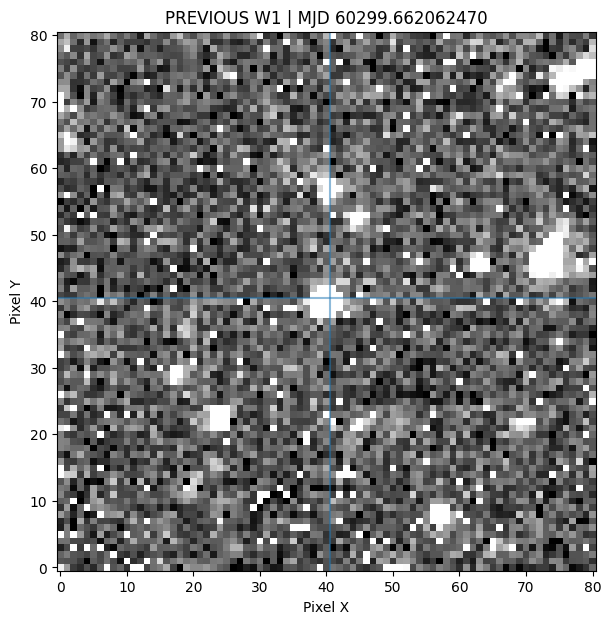

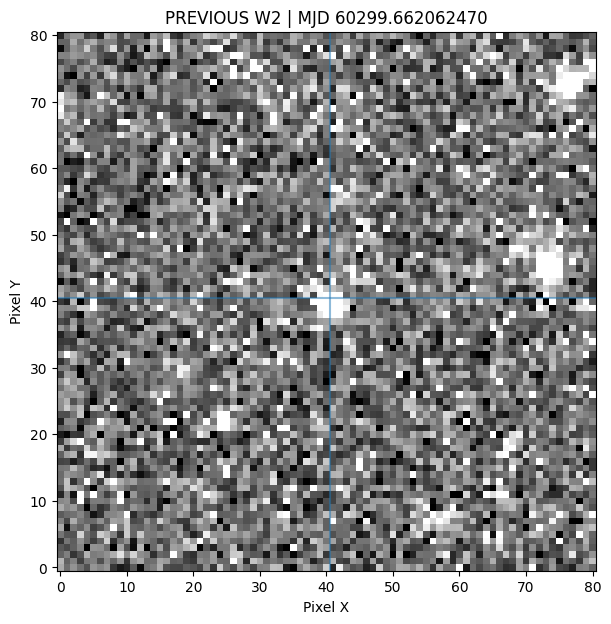

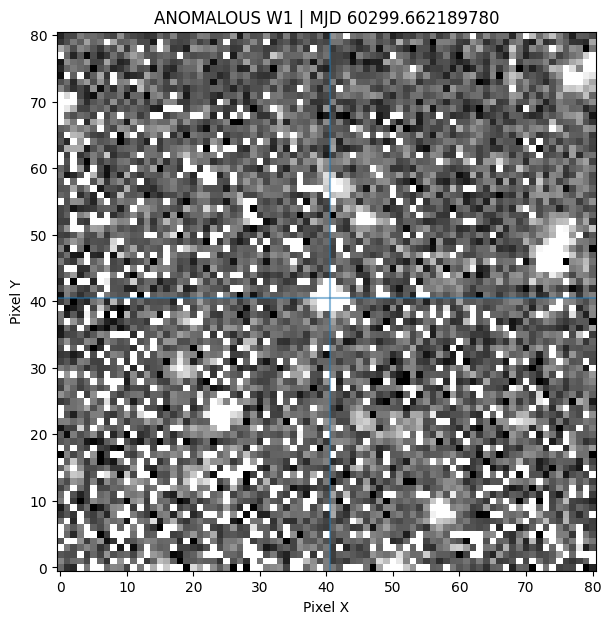

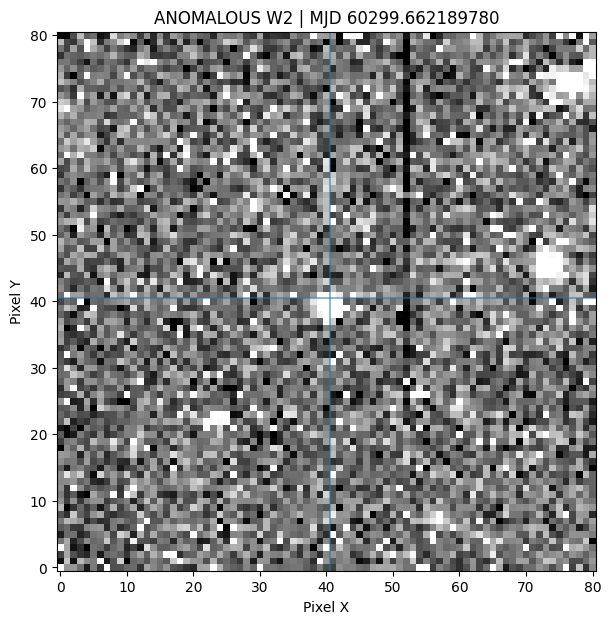

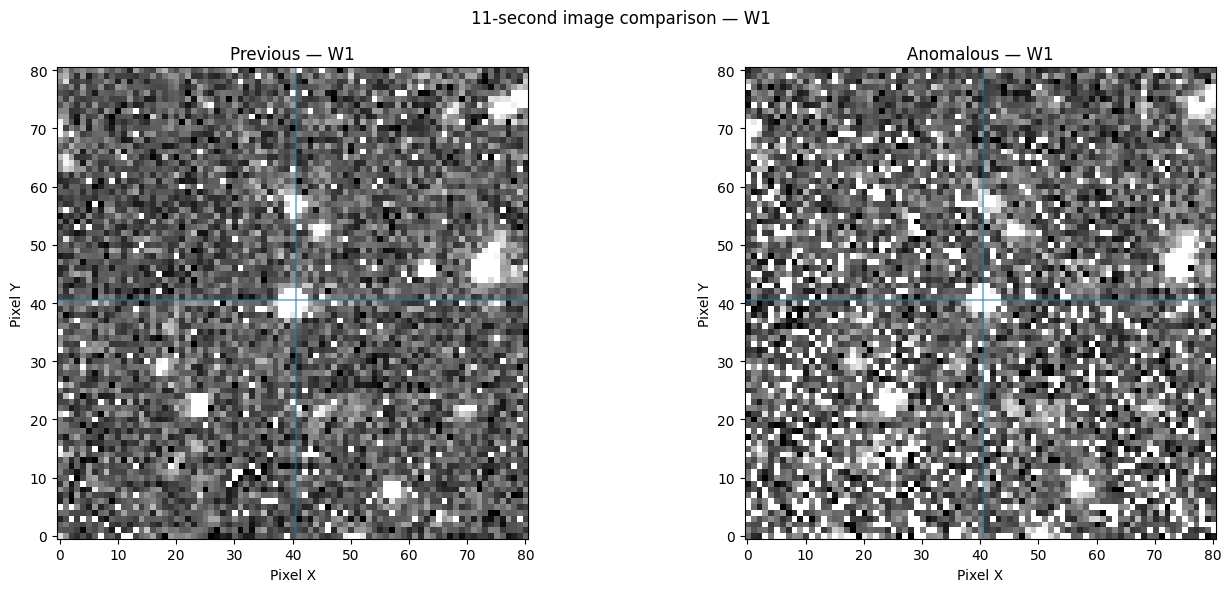

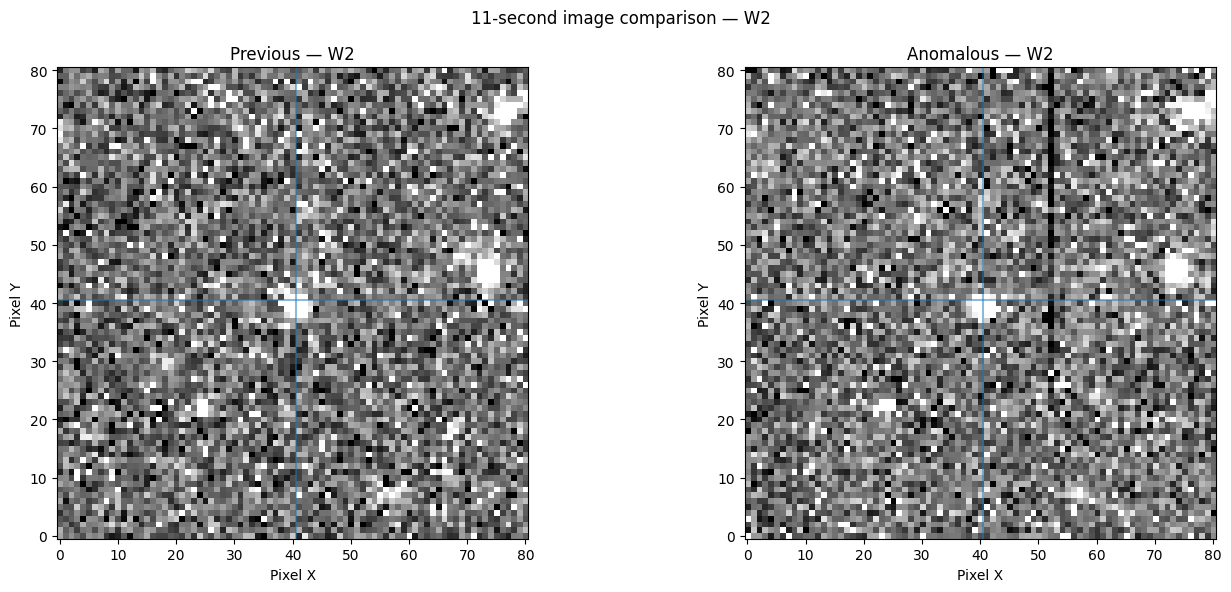

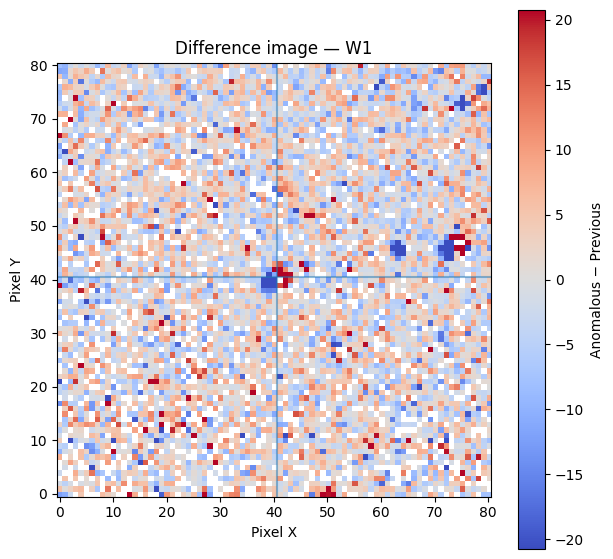

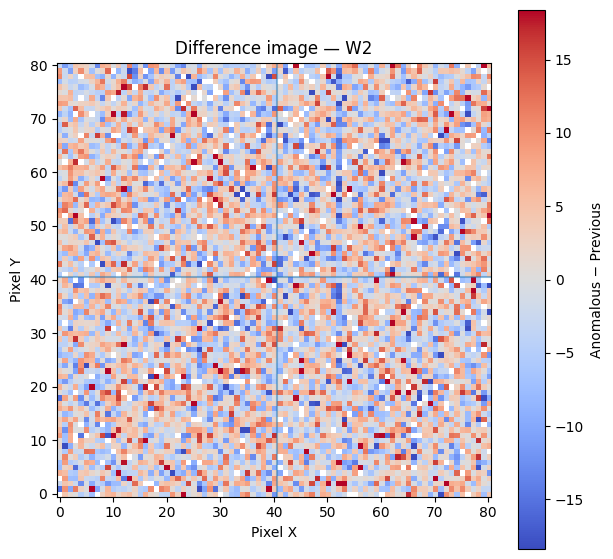


ARTIFACT CHECK — PREVIOUS W1

Checking diffraction spikes:
Artifact positions: 132
Nearest artifact: 521.598 arcsec

Checking optical ghosts:
No table returned.

Checking latents:
Artifact positions: 4
Nearest artifact: 1513.146 arcsec

Checking halos:
Artifact positions: 215
Nearest artifact: 545.924 arcsec

ARTIFACT CHECK — PREVIOUS W2

Checking diffraction spikes:
Artifact positions: 63
Nearest artifact: 2123.811 arcsec

Checking optical ghosts:
Artifact positions: 7
Nearest artifact: 2508.627 arcsec

Checking latents:
Artifact positions: 2
Nearest artifact: 2365.000 arcsec

Checking halos:
Artifact positions: 25
Nearest artifact: 575.878 arcsec

ARTIFACT CHECK — ANOMALOUS W1

Checking diffraction spikes:
Artifact positions: 21
Nearest artifact: 416.091 arcsec

Checking optical ghosts:
No table returned.

Checking latents:
Artifact positions: 5
Nearest artifact: 867.238 arcsec

Checking halos:
Artifact positions: 37
Nearest artifact: 436.470 arcsec

ARTIFACT CHECK — ANOMALOUS W2

C

In [ ]:
# ================================================================
# EXP-001 — FINAL IRSA IMAGE RETRIEVAL + ARTIFACT CHECK
#
# Strongest candidate:
#
#   RA  = 179.936465
#   Dec = -0.0897475
#
# Previous:
#   scan_id   = 57306r
#   frame_num = 138
#   MJD       = 60299.66206247
#
# Anomalous:
#   scan_id   = 57306r
#   frame_num = 139
#   MJD       = 60299.66218978
#
# ================================================================

import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u


# ================================================================
# 1. TARGET
# ================================================================

RA_TARGET = 179.936465
DEC_TARGET = -0.0897475

FRAME_INFO = [
    {
        "label": "previous",
        "scan_id": "57306r",
        "frame_num": 138,
        "mjd": 60299.66206247,
    },
    {
        "label": "anomalous",
        "scan_id": "57306r",
        "frame_num": 139,
        "mjd": 60299.66218978,
    },
]


# ================================================================
# 2. IRSA ROOT
# ================================================================

IRSA_ROOT = (
    "https://irsa.ipac.caltech.edu"
)

IRSA_DATA_ROOT = (
    f"{IRSA_ROOT}/ibe/data/wise/neowiser/p1bm_frm"
)


# ================================================================
# 3. BUILD EXACT IRSA IMAGE URL
# ================================================================

def build_image_url(scan_id, frame_num, band):

    scangrp = scan_id[-2:]

    filename = (
        f"{scan_id}{frame_num:03d}"
        f"-w{band}-int-1b.fits"
    )

    return (
        f"{IRSA_DATA_ROOT}/"
        f"{scangrp}/"
        f"{scan_id}/"
        f"{frame_num:03d}/"
        f"{filename}"
    )


# ================================================================
# 4. DOWNLOAD CUTOUT SAFELY
# ================================================================

def download_cutout(scan_id, frame_num, band):

    base_url = build_image_url(
        scan_id,
        frame_num,
        band
    )

    params = {
        "center": f"{RA_TARGET},{DEC_TARGET}",
        "size": "80pix",
        "gzip": "false",
    }

    print()
    print("=" * 70)
    print(f"REQUESTING W{band}")
    print(f"scan_id   : {scan_id}")
    print(f"frame_num : {frame_num}")
    print("=" * 70)

    print("Base URL:")
    print(base_url)

    try:

        r = requests.get(
            base_url,
            params=params,
            timeout=120
        )

    except Exception as e:

        print("REQUEST ERROR:")
        print(type(e).__name__, e)

        return None

    print()
    print("HTTP status :", r.status_code)
    print("Content-Type:", r.headers.get("Content-Type"))
    print("Bytes       :", len(r.content))

    print()
    print("Final URL:")
    print(r.url)

    # ------------------------------------------------------------
    # FITS files normally begin with SIMPLE in the header.
    # Check the actual response before handing it to astropy.
    # ------------------------------------------------------------

    first_bytes = r.content[:200]

    print()
    print("First response bytes:")
    print(first_bytes[:120])

    # ------------------------------------------------------------
    # If server returned an error page or text, show it.
    # ------------------------------------------------------------

    content_type = (
        r.headers.get("Content-Type", "")
        .lower()
    )

    if r.status_code != 200:

        print()
        print("IRSA returned a non-200 response.")

        try:
            print(r.text[:1000])
        except:
            pass

        return None

    # ------------------------------------------------------------
    # Try FITS directly.
    #
    # We use ignore_missing_simple=True because some FITS products
    # can be valid even when SIMPLE is not the first recognizable
    # card.
    # ------------------------------------------------------------

    try:

        hdul = fits.open(
            io.BytesIO(r.content),
            ignore_missing_simple=True
        )

        print()
        print("SUCCESS: Astropy opened the response as FITS.")

        print()
        hdul.info()

        return hdul

    except Exception as e:

        print()
        print("NOT A USABLE FITS RESPONSE")
        print(type(e).__name__, ":", e)

        print()
        print("Response text preview:")

        try:
            print(r.text[:2000])
        except:
            print("<binary response>")

        return None


# ================================================================
# 5. DOWNLOAD FOUR IMAGES
# ================================================================

images = {}

for frame in FRAME_INFO:

    for band in [1, 2]:

        key = (
            frame["label"],
            band
        )

        hdul = download_cutout(
            frame["scan_id"],
            frame["frame_num"],
            band
        )

        if hdul is not None:

            images[key] = {
                "label": frame["label"],
                "band": band,
                "scan_id": frame["scan_id"],
                "frame_num": frame["frame_num"],
                "mjd": frame["mjd"],
                "hdul": hdul,
            }


# ================================================================
# 6. FIND THE 2-D IMAGE HDU
# ================================================================

def get_image_hdu(hdul):

    for i, hdu in enumerate(hdul):

        if hdu.data is None:
            continue

        try:
            data = np.asarray(
                hdu.data,
                dtype=float
            )
        except:
            continue

        if data.ndim == 2:

            return i, data, hdu.header

    return None, None, None


# ================================================================
# 7. EXTRACT IMAGES
# ================================================================

image_arrays = {}

for key, item in images.items():

    hdu_index, data, header = get_image_hdu(
        item["hdul"]
    )

    if data is None:

        print(
            "No 2-D image found:",
            key
        )

        continue

    image_arrays[key] = {
        **item,
        "data": data,
        "header": header,
        "hdu_index": hdu_index,
    }

    print()
    print(
        f"Loaded {key}:",
        data.shape
    )


# ================================================================
# 8. PRINT IMAGE STATISTICS
# ================================================================

print()
print("=" * 70)
print("IMAGE STATISTICS")
print("=" * 70)

for key, item in image_arrays.items():

    data = item["data"]

    finite = data[
        np.isfinite(data)
    ]

    if len(finite) == 0:
        continue

    print()
    print(
        key,
        "MJD:",
        item["mjd"]
    )

    print(
        "shape   :",
        data.shape
    )

    print(
        "median  :",
        np.nanmedian(finite)
    )

    print(
        "std     :",
        np.nanstd(finite)
    )

    print(
        "min     :",
        np.nanmin(finite)
    )

    print(
        "max     :",
        np.nanmax(finite)
    )


# ================================================================
# 9. DISPLAY INDIVIDUAL IMAGES
# ================================================================

def robust_limits(data):

    finite = data[
        np.isfinite(data)
    ]

    if len(finite) == 0:
        return 0, 1

    lo = np.nanpercentile(
        finite,
        2
    )

    hi = np.nanpercentile(
        finite,
        98
    )

    return lo, hi


for key, item in image_arrays.items():

    data = item["data"]

    lo, hi = robust_limits(
        data
    )

    plt.figure(
        figsize=(7, 7)
    )

    plt.imshow(
        data,
        origin="lower",
        cmap="gray",
        vmin=lo,
        vmax=hi
    )

    # Center of requested cutout
    cx = data.shape[1] / 2
    cy = data.shape[0] / 2

    plt.axvline(
        cx,
        alpha=0.5
    )

    plt.axhline(
        cy,
        alpha=0.5
    )

    plt.title(
        f"{item['label'].upper()} "
        f"W{item['band']} | "
        f"MJD {item['mjd']:.9f}"
    )

    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")

    plt.show()


# ================================================================
# 10. SIDE-BY-SIDE PREVIOUS VS ANOMALOUS
# ================================================================

for band in [1, 2]:

    previous_key = (
        "previous",
        band
    )

    anomalous_key = (
        "anomalous",
        band
    )

    if (
        previous_key not in image_arrays
        or
        anomalous_key not in image_arrays
    ):
        print(
            f"Cannot compare W{band}: "
            "one or both images missing."
        )
        continue

    previous = image_arrays[
        previous_key
    ]["data"]

    anomalous = image_arrays[
        anomalous_key
    ]["data"]

    # Common display limits
    combined = np.concatenate([
        previous[
            np.isfinite(previous)
        ],
        anomalous[
            np.isfinite(anomalous)
        ]
    ])

    lo = np.nanpercentile(
        combined,
        2
    )

    hi = np.nanpercentile(
        combined,
        98
    )

    fig = plt.figure(
        figsize=(14, 6)
    )

    ax1 = fig.add_subplot(
        1, 2, 1
    )

    ax1.imshow(
        previous,
        origin="lower",
        cmap="gray",
        vmin=lo,
        vmax=hi
    )

    ax1.axvline(
        previous.shape[1] / 2,
        alpha=0.5
    )

    ax1.axhline(
        previous.shape[0] / 2,
        alpha=0.5
    )

    ax1.set_title(
        f"Previous — W{band}"
    )

    ax1.set_xlabel("Pixel X")
    ax1.set_ylabel("Pixel Y")

    ax2 = fig.add_subplot(
        1, 2, 2
    )

    ax2.imshow(
        anomalous,
        origin="lower",
        cmap="gray",
        vmin=lo,
        vmax=hi
    )

    ax2.axvline(
        anomalous.shape[1] / 2,
        alpha=0.5
    )

    ax2.axhline(
        anomalous.shape[0] / 2,
        alpha=0.5
    )

    ax2.set_title(
        f"Anomalous — W{band}"
    )

    ax2.set_xlabel("Pixel X")
    ax2.set_ylabel("Pixel Y")

    fig.suptitle(
        f"11-second image comparison — W{band}"
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 11. DIFFERENCE IMAGES
# ================================================================

for band in [1, 2]:

    previous_key = (
        "previous",
        band
    )

    anomalous_key = (
        "anomalous",
        band
    )

    if (
        previous_key not in image_arrays
        or
        anomalous_key not in image_arrays
    ):
        continue

    previous = image_arrays[
        previous_key
    ]["data"]

    anomalous = image_arrays[
        anomalous_key
    ]["data"]

    if previous.shape != anomalous.shape:

        print(
            f"W{band}: shapes differ; "
            "skipping difference image."
        )

        continue

    difference = (
        anomalous - previous
    )

    finite = difference[
        np.isfinite(difference)
    ]

    if len(finite) == 0:
        continue

    limit = np.nanpercentile(
        np.abs(finite),
        98
    )

    plt.figure(
        figsize=(7, 7)
    )

    plt.imshow(
        difference,
        origin="lower",
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit
    )

    plt.axvline(
        difference.shape[1] / 2,
        alpha=0.5
    )

    plt.axhline(
        difference.shape[0] / 2,
        alpha=0.5
    )

    plt.colorbar(
        label="Anomalous − Previous"
    )

    plt.title(
        f"Difference image — W{band}"
    )

    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")

    plt.show()


# ================================================================
# 12. QUERY OFFICIAL NEOWISER ARTIFACT TABLES
#
# IRSA documents four artifact-position tables:
#
#   D = diffraction spikes
#   O = optical ghosts
#   P = latents
#   H = halos
#
# These are associated with the exact L1b frame.
# ================================================================

def artifact_url(
    scan_id,
    frame_num,
    band,
    artifact_code
):

    scangrp = scan_id[-2:]

    filename = (
        f"{scan_id}{frame_num:03d}"
        f"-art-w{band}-{artifact_code}.tbl"
    )

    return (
        f"{IRSA_DATA_ROOT}/"
        f"{scangrp}/"
        f"{scan_id}/"
        f"{frame_num:03d}/"
        f"{filename}"
    )


def check_artifacts(
    scan_id,
    frame_num,
    band
):

    artifact_names = {
        "D": "diffraction spikes",
        "O": "optical ghosts",
        "P": "latents",
        "H": "halos",
    }

    results = []

    target = SkyCoord(
        RA_TARGET,
        DEC_TARGET,
        unit="deg",
        frame="icrs"
    )

    for code, name in artifact_names.items():

        url = artifact_url(
            scan_id,
            frame_num,
            band,
            code
        )

        print()
        print(
            f"Checking {name}:"
        )

        try:

            r = requests.get(
                url,
                timeout=60
            )

        except Exception as e:

            print(
                "Request failed:",
                e
            )

            continue

        # 404 means IRSA has no artifact table
        # for that frame/type.
        if r.status_code == 404:

            print(
                "No table returned."
            )

            continue

        if r.status_code != 200:

            print(
                "HTTP status:",
                r.status_code
            )

            continue

        try:

            text = r.text.strip()

            if not text:
                continue

            # IPAC tables can contain metadata/header lines.
            # Extract numeric RA/Dec rows conservatively.

            rows = []

            for line in text.splitlines():

                line = line.strip()

                if (
                    not line
                    or line.startswith("\\")
                    or line.startswith("|")
                    or line.startswith("\\")
                ):
                    continue

                parts = line.split()

                if len(parts) < 2:
                    continue

                try:

                    ra = float(parts[0])
                    dec = float(parts[1])

                    if (
                        0 <= ra <= 360
                        and
                        -90 <= dec <= 90
                    ):

                        rows.append(
                            (ra, dec)
                        )

                except:
                    continue

            if len(rows) == 0:

                print(
                    "Table exists but "
                    "no coordinate rows parsed."
                )

                continue

            coords = SkyCoord(
                [r[0] for r in rows],
                [r[1] for r in rows],
                unit="deg",
                frame="icrs"
            )

            separations = (
                target.separation(
                    coords
                ).arcsec
            )

            nearest = np.argmin(
                separations
            )

            nearest_sep = (
                separations[nearest]
            )

            print(
                f"Artifact positions: {len(rows)}"
            )

            print(
                f"Nearest artifact: "
                f"{nearest_sep:.3f} arcsec"
            )

            results.append({
                "band": band,
                "artifact": name,
                "count": len(rows),
                "nearest_arcsec": nearest_sep,
                "ra": rows[nearest][0],
                "dec": rows[nearest][1],
            })

        except Exception as e:

            print(
                "Could not parse artifact table:",
                type(e).__name__,
                e
            )

    return results


# ================================================================
# 13. RUN ARTIFACT CHECKS
# ================================================================

artifact_results = []

for frame in FRAME_INFO:

    for band in [1, 2]:

        print()
        print("=" * 70)
        print(
            f"ARTIFACT CHECK — "
            f"{frame['label'].upper()} W{band}"
        )
        print("=" * 70)

        result = check_artifacts(
            frame["scan_id"],
            frame["frame_num"],
            band
        )

        artifact_results.extend(
            result
        )


# ================================================================
# 14. ARTIFACT SUMMARY
# ================================================================

print()
print("=" * 70)
print("ARTIFACT SUMMARY")
print("=" * 70)

if len(artifact_results) == 0:

    print("""
No artifact-position matches were returned.

IMPORTANT:
This does NOT prove the measurement is astrophysical.

It only means the target was not matched to an artifact
position in the artifact tables that were successfully queried.
""")

else:

    artifact_df = pd.DataFrame(
        artifact_results
    )

    print(
        artifact_df.to_string(
            index=False
        )
    )


# ================================================================
# 15. FINAL STATUS
# ================================================================

print()
print("=" * 70)
print("EXP-001 FINAL STATUS")
print("=" * 70)

print(
    f"""
Target:
    RA  = {RA_TARGET}
    Dec = {DEC_TARGET}

Strongest photometric event:
    ΔW1 = +0.185 mag
    ZW1 = +4.29 sigma

    ΔW2 = +0.197 mag
    ZW2 = +2.42 sigma

Images successfully loaded:
    {len(image_arrays)} / 4

Artifact checks completed:
    {len(artifact_results)} artifact-table matches/results

Scientific interpretation:

    We are testing whether the 4.29-sigma W1 excursion
    can be explained by the image itself, rather than
    immediately interpreting it as astrophysical variability.

Possible outcomes:

    A. Obvious image artifact
       -> candidate becomes much weaker.

    B. Blending/source confusion
       -> candidate becomes much weaker.

    C. Bad/structured background
       -> candidate becomes weaker.

    D. Position/PSF problem
       -> candidate becomes weaker.

    E. Image looks clean and isolated
       -> candidate becomes more interesting,
          but is NOT yet a discovery.

Next scientific stage after image inspection:

    independent-survey / multi-survey verification.

That is the important transition from:

    "interesting NEOWISE measurement"

to:

    "candidate unusual astronomical behavior."
"""
)

In [ ]:
pip install astropy numpy scipy matplotlib

In [ ]:

import io
import requests
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from scipy.ndimage import shift as ndimage_shift
from scipy.optimize import least_squares


# ============================================================
# EXP-002 — CENTROID + PSF VERIFICATION
# ============================================================

TARGET_RA = 179.936465
TARGET_DEC = -0.0897475

SCAN_ID = "57306r"

PREVIOUS_FRAME = 138
ANOMALOUS_FRAME = 139


# ============================================================
# IRSA DOWNLOAD
# ============================================================

def download_wise_cutout(scan_id, frame_num, band):
    """
    Download an 80-pixel IRSA WISE cutout directly into memory.
    """

    url = (
        f"https://irsa.ipac.caltech.edu/ibe/data/wise/neowiser/"
        f"p1bm_frm/6r/{scan_id}/{frame_num}/"
        f"{scan_id}{frame_num}-w{band}-int-1b.fits"
    )

    params = {
        "center": f"{TARGET_RA},{TARGET_DEC}",
        "size": "80pix",
        "gzip": "false",
    }

    print()
    print(f"REQUESTING W{band}")
    print(f"scan_id   : {scan_id}")
    print(f"frame_num : {frame_num}")
    print("-" * 60)

    response = requests.get(
        url,
        params=params,
        timeout=60
    )

    print("HTTP status :", response.status_code)
    print("Bytes       :", len(response.content))
    print("Final URL   :", response.url)

    response.raise_for_status()

    with fits.open(io.BytesIO(response.content)) as hdul:
        data = hdul[0].data.astype(np.float64)

    print("FITS shape  :", data.shape)

    return data


# ============================================================
# DOWNLOAD ALL FOUR IMAGES
# ============================================================

previous_w1 = download_wise_cutout(
    SCAN_ID,
    PREVIOUS_FRAME,
    1
)

previous_w2 = download_wise_cutout(
    SCAN_ID,
    PREVIOUS_FRAME,
    2
)

anomalous_w1 = download_wise_cutout(
    SCAN_ID,
    ANOMALOUS_FRAME,
    1
)

anomalous_w2 = download_wise_cutout(
    SCAN_ID,
    ANOMALOUS_FRAME,
    2
)


# ============================================================
# VERIFY
# ============================================================

print()
print("=" * 70)
print("EXP-002 — IMAGE LOADING COMPLETE")
print("=" * 70)

print("Previous W1 :", previous_w1.shape)
print("Previous W2 :", previous_w2.shape)
print("Anomalous W1:", anomalous_w1.shape)
print("Anomalous W2:", anomalous_w2.shape)


# ============================================================
# CENTROID ESTIMATION
# ============================================================

def centroid_weighted(image, radius=6):

    image = np.asarray(image, dtype=float)

    background = np.nanmedian(image)
    data = image - background

    ny, nx = data.shape

    cx_center = (nx - 1) / 2
    cy_center = (ny - 1) / 2

    yy, xx = np.indices(data.shape)

    central_mask = (
        (xx - cx_center) ** 2 +
        (yy - cy_center) ** 2
    ) <= 15 ** 2

    masked = np.where(
        central_mask,
        data,
        -np.inf
    )

    peak_y, peak_x = np.unravel_index(
        np.nanargmax(masked),
        data.shape
    )

    aperture = (
        (xx - peak_x) ** 2 +
        (yy - peak_y) ** 2
    ) <= radius ** 2

    flux = np.where(
        aperture,
        data,
        0.0
    )

    flux = np.maximum(flux, 0.0)

    total = np.sum(flux)

    if total <= 0:
        raise RuntimeError(
            "Unable to calculate positive centroid."
        )

    centroid_x = np.sum(xx * flux) / total
    centroid_y = np.sum(yy * flux) / total

    return (
        centroid_x,
        centroid_y,
        peak_x,
        peak_y
    )


# ============================================================
# W1 CENTROIDS
# ============================================================

print()
print("=" * 70)
print("W1 CENTROID ANALYSIS")
print("=" * 70)

prev_cx, prev_cy, prev_px, prev_py = centroid_weighted(
    previous_w1
)

anom_cx, anom_cy, anom_px, anom_py = centroid_weighted(
    anomalous_w1
)

print()
print("PREVIOUS W1")
print(f"Centroid X : {prev_cx:.5f}")
print(f"Centroid Y : {prev_cy:.5f}")
print(f"Peak pixel : ({prev_px}, {prev_py})")

print()
print("ANOMALOUS W1")
print(f"Centroid X : {anom_cx:.5f}")
print(f"Centroid Y : {anom_cy:.5f}")
print(f"Peak pixel : ({anom_px}, {anom_py})")


dx = anom_cx - prev_cx
dy = anom_cy - prev_cy

total_shift = np.sqrt(
    dx**2 + dy**2
)

print()
print("CENTROID DISPLACEMENT")
print(f"ΔX : {dx:+.5f} pixels")
print(f"ΔY : {dy:+.5f} pixels")
print(f"Total : {total_shift:.5f} pixels")


# ============================================================
# 2D GAUSSIAN MODEL
# ============================================================

def gaussian_2d(
    params,
    x,
    y
):

    amplitude, x0, y0, sigma_x, sigma_y, background = params

    sigma_x = max(abs(sigma_x), 0.05)
    sigma_y = max(abs(sigma_y), 0.05)

    return (
        background
        +
        amplitude
        *
        np.exp(
            -0.5
            *
            (
                ((x - x0) / sigma_x) ** 2
                +
                ((y - y0) / sigma_y) ** 2
            )
        )
    )


# ============================================================
# PSF FIT
# ============================================================

def fit_psf(
    image,
    centroid_x,
    centroid_y,
    half_size=7
):

    x_min = max(
        0,
        int(np.floor(centroid_x)) - half_size
    )

    x_max = min(
        image.shape[1],
        int(np.floor(centroid_x)) + half_size + 1
    )

    y_min = max(
        0,
        int(np.floor(centroid_y)) - half_size
    )

    y_max = min(
        image.shape[0],
        int(np.floor(centroid_y)) + half_size + 1
    )

    cutout = image[
        y_min:y_max,
        x_min:x_max
    ]

    yy, xx = np.indices(cutout.shape)

    x_absolute = xx + x_min
    y_absolute = yy + y_min

    background = np.median(cutout)

    amplitude = np.max(cutout) - background

    initial = np.array([
        amplitude,
        centroid_x,
        centroid_y,
        2.0,
        2.0,
        background
    ])

    def residuals(params):

        model = gaussian_2d(
            params,
            x_absolute,
            y_absolute
        )

        return (
            model - cutout
        ).ravel()

    result = least_squares(
        residuals,
        initial,
        bounds=(
            [
                0,
                centroid_x - 3,
                centroid_y - 3,
                0.2,
                0.2,
                -np.inf
            ],
            [
                np.inf,
                centroid_x + 3,
                centroid_y + 3,
                10,
                10,
                np.inf
            ]
        )
    )

    (
        amplitude,
        x0,
        y0,
        sigma_x,
        sigma_y,
        background
    ) = result.x

    fwhm_x = (
        2.354820045 *
        abs(sigma_x)
    )

    fwhm_y = (
        2.354820045 *
        abs(sigma_y)
    )

    model = gaussian_2d(
        result.x,
        x_absolute,
        y_absolute
    )

    residual = (
        cutout -
        model
    )

    rms = np.sqrt(
        np.mean(residual**2)
    )

    return {
        "x": x0,
        "y": y0,
        "sigma_x": abs(sigma_x),
        "sigma_y": abs(sigma_y),
        "fwhm_x": fwhm_x,
        "fwhm_y": fwhm_y,
        "background": background,
        "amplitude": amplitude,
        "rms": rms
    }


# ============================================================
# FIT PSFs
# ============================================================

print()
print("=" * 70)
print("W1 PSF ANALYSIS")
print("=" * 70)

prev_psf = fit_psf(
    previous_w1,
    prev_cx,
    prev_cy
)

anom_psf = fit_psf(
    anomalous_w1,
    anom_cx,
    anom_cy
)


print()
print("PREVIOUS W1 PSF")

print(
    f"Centroid : "
    f"({prev_psf['x']:.5f}, "
    f"{prev_psf['y']:.5f})"
)

print(
    f"Sigma X  : "
    f"{prev_psf['sigma_x']:.5f}"
)

print(
    f"Sigma Y  : "
    f"{prev_psf['sigma_y']:.5f}"
)

print(
    f"FWHM X   : "
    f"{prev_psf['fwhm_x']:.5f}"
)

print(
    f"FWHM Y   : "
    f"{prev_psf['fwhm_y']:.5f}"
)

print(
    f"Fit RMS  : "
    f"{prev_psf['rms']:.5f}"
)


print()
print("ANOMALOUS W1 PSF")

print(
    f"Centroid : "
    f"({anom_psf['x']:.5f}, "
    f"{anom_psf['y']:.5f})"
)

print(
    f"Sigma X  : "
    f"{anom_psf['sigma_x']:.5f}"
)

print(
    f"Sigma Y  : "
    f"{anom_psf['sigma_y']:.5f}"
)

print(
    f"FWHM X   : "
    f"{anom_psf['fwhm_x']:.5f}"
)

print(
    f"FWHM Y   : "
    f"{anom_psf['fwhm_y']:.5f}"
)

print(
    f"Fit RMS  : "
    f"{anom_psf['rms']:.5f}"
)


# ============================================================
# PSF CHANGES
# ============================================================

delta_fwhm_x = (
    anom_psf["fwhm_x"]
    -
    prev_psf["fwhm_x"]
)

delta_fwhm_y = (
    anom_psf["fwhm_y"]
    -
    prev_psf["fwhm_y"]
)

print()
print("PSF CHANGE")

print(
    f"ΔFWHM X : "
    f"{delta_fwhm_x:+.5f} pixels"
)

print(
    f"ΔFWHM Y : "
    f"{delta_fwhm_y:+.5f} pixels"
)


# ============================================================
# RAW DIFFERENCE
# ============================================================

raw_difference = (
    anomalous_w1 -
    previous_w1
)


# ============================================================
# REGISTER ANOMALOUS IMAGE
# ============================================================

print()
print("=" * 70)
print("IMAGE REGISTRATION")
print("=" * 70)

registered_anomalous_w1 = ndimage_shift(
    anomalous_w1,
    shift=(-dy, -dx),
    order=3,
    mode="nearest"
)

registered_difference = (
    registered_anomalous_w1 -
    previous_w1
)


# ============================================================
# LOCAL DIFFERENCE METRICS
# ============================================================

def difference_metrics(
    diff,
    cx,
    cy,
    radius=5
):

    yy, xx = np.indices(
        diff.shape
    )

    aperture = (
        (xx - cx)**2 +
        (yy - cy)**2
    ) <= radius**2

    values = diff[aperture]

    return {
        "max": np.max(values),
        "min": np.min(values),
        "std": np.std(values),
        "mean": np.mean(values),
        "abs_max": np.max(
            np.abs(values)
        )
    }


raw_metrics = difference_metrics(
    raw_difference,
    prev_cx,
    prev_cy
)

registered_metrics = difference_metrics(
    registered_difference,
    prev_cx,
    prev_cy
)


print()
print("RAW DIFFERENCE")

print(
    f"Max  : "
    f"{raw_metrics['max']:+.5f}"
)

print(
    f"Min  : "
    f"{raw_metrics['min']:+.5f}"
)

print(
    f"Std  : "
    f"{raw_metrics['std']:.5f}"
)

print(
    f"Mean : "
    f"{raw_metrics['mean']:+.5f}"
)


print()
print("REGISTERED DIFFERENCE")

print(
    f"Max  : "
    f"{registered_metrics['max']:+.5f}"
)

print(
    f"Min  : "
    f"{registered_metrics['min']:+.5f}"
)

print(
    f"Std  : "
    f"{registered_metrics['std']:.5f}"
)

print(
    f"Mean : "
    f"{registered_metrics['mean']:+.5f}"
)


# ============================================================
# RESIDUAL REDUCTION
# ============================================================

raw_abs = raw_metrics["abs_max"]

registered_abs = (
    registered_metrics["abs_max"]
)

if raw_abs > 0:

    reduction = (
        1 -
        registered_abs /
        raw_abs
    ) * 100

else:

    reduction = 0.0


print()
print(
    "Maximum absolute residual reduction:"
)

print(
    f"{reduction:.2f}%"
)


# ============================================================
# FINAL INTERPRETATION
# ============================================================

print()
print("=" * 70)
print("EXP-002 SCIENTIFIC INTERPRETATION")
print("=" * 70)

print()
print(
    f"Centroid displacement:"
    f" {total_shift:.5f} pixels"
)

print(
    f"ΔFWHM X:"
    f" {delta_fwhm_x:+.5f} pixels"
)

print(
    f"ΔFWHM Y:"
    f" {delta_fwhm_y:+.5f} pixels"
)

print(
    f"Residual reduction:"
    f" {reduction:.2f}%"
)

print()


if total_shift >= 0.10 and reduction >= 30:

    print(
        "CLASSIFICATION:"
    )

    print(
        "Outcome D SUPPORTED — "
        "position/registration systematic is a "
        "strong explanation."
    )

elif total_shift >= 0.10:

    print(
        "CLASSIFICATION:"
    )

    print(
        "Centroid displacement detected, "
        "but simple registration does not "
        "remove the residual sufficiently."
    )

else:

    print(
        "CLASSIFICATION:"
    )

    print(
        "No strong centroid displacement detected."
    )

    print(
        "A simple positional shift does not "
        "adequately explain the W1 excursion."
    )


# ============================================================
# VISUAL DIAGNOSTIC
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)


# Previous
vmin = np.percentile(
    previous_w1,
    2
)

vmax = np.percentile(
    previous_w1,
    98
)

axes[0].imshow(
    previous_w1,
    origin="lower",
    vmin=vmin,
    vmax=vmax
)

axes[0].scatter(
    prev_cx,
    prev_cy,
    marker="+",
    s=120
)

axes[0].set_title(
    "Previous W1"
)


# Anomalous
axes[1].imshow(
    anomalous_w1,
    origin="lower",
    vmin=vmin,
    vmax=vmax
)

axes[1].scatter(
    anom_cx,
    anom_cy,
    marker="+",
    s=120
)

axes[1].set_title(
    "Anomalous W1"
)


# Raw difference
raw_limit = np.percentile(
    np.abs(raw_difference),
    99
)

axes[2].imshow(
    raw_difference,
    origin="lower",
    vmin=-raw_limit,
    vmax=raw_limit
)

axes[2].set_title(
    "Raw Difference"
)


# Registered difference
registered_limit = np.percentile(
    np.abs(registered_difference),
    99
)

axes[3].imshow(
    registered_difference,
    origin="lower",
    vmin=-registered_limit,
    vmax=registered_limit
)

axes[3].set_title(
    "Registered Difference"
)


for ax in axes:
    ax.set_xlabel("X pixel")

axes[0].set_ylabel("Y pixel")

plt.tight_layout()

plt.savefig(
    "EXP-002_centroid_psf_diagnostic.png",
    dpi=200
)

plt.show()


print()
print("=" * 70)
print("EXP-002 COMPLETE")
print("=" * 70)

print(
    "Diagnostic saved as:"
)

print(
    "EXP-002_centroid_psf_diagnostic.png"
)


REQUESTING W1
scan_id   : 57306r
frame_num : 138
------------------------------------------------------------
HTTP status : 200
Bytes       : 66240
Final URL   : https://irsa.ipac.caltech.edu/ibe/data/wise/neowiser/p1bm_frm/6r/57306r/138/57306r138-w1-int-1b.fits?center=179.936465%2C-0.0897475&size=80pix&gzip=false
FITS shape  : (81, 81)

REQUESTING W2
scan_id   : 57306r
frame_num : 138
------------------------------------------------------------
HTTP status : 200
Bytes       : 69120
Final URL   : https://irsa.ipac.caltech.edu/ibe/data/wise/neowiser/p1bm_frm/6r/57306r/138/57306r138-w2-int-1b.fits?center=179.936465%2C-0.0897475&size=80pix&gzip=false
FITS shape  : (81, 81)

REQUESTING W1
scan_id   : 57306r
frame_num : 139
------------------------------------------------------------
HTTP status : 200
Bytes       : 66240
Final URL   : https://irsa.ipac.caltech.edu/ibe/data/wise/neowiser/p1bm_frm/6r/57306r/139/57306r139-w1-int-1b.fits?center=179.936465%2C-0.0897475&size=80pix&gzip=false
FIT

ValueError: cannot convert float NaN to integer

EXP-002B — ROBUST IMAGE-LEVEL ANALYSIS

W1 SOURCE LOCATIONS
----------------------------------------------------------------------
Previous:
  Peak      : (73, 46)
  Centroid  : (73.2570, 46.3157)

Anomalous:
  Peak      : (74, 46)
  Centroid  : (74.0126, 46.6396)

CENTROID DISPLACEMENT
----------------------------------------------------------------------
ΔX       : +0.7556 pixels
ΔY       : +0.3240 pixels
Total    : 0.8221 pixels

W1 IMAGE STATISTICS
----------------------------------------------------------------------
median              : 28.926711
robust_sigma        : 4.165815
peak                : 325.459839
source_peak         : 325.459839
source_excess       : 2137.577727
n_source_pixels     : 77.000000

ANOMALOUS W1
median              : 29.323110
robust_sigma        : 4.561261
peak                : 281.961212
source_peak         : 281.961212
source_excess       : 1900.513656
n_source_pixels     : 73.000000

RADIAL SOURCE PROFILE
---------------------------------------------

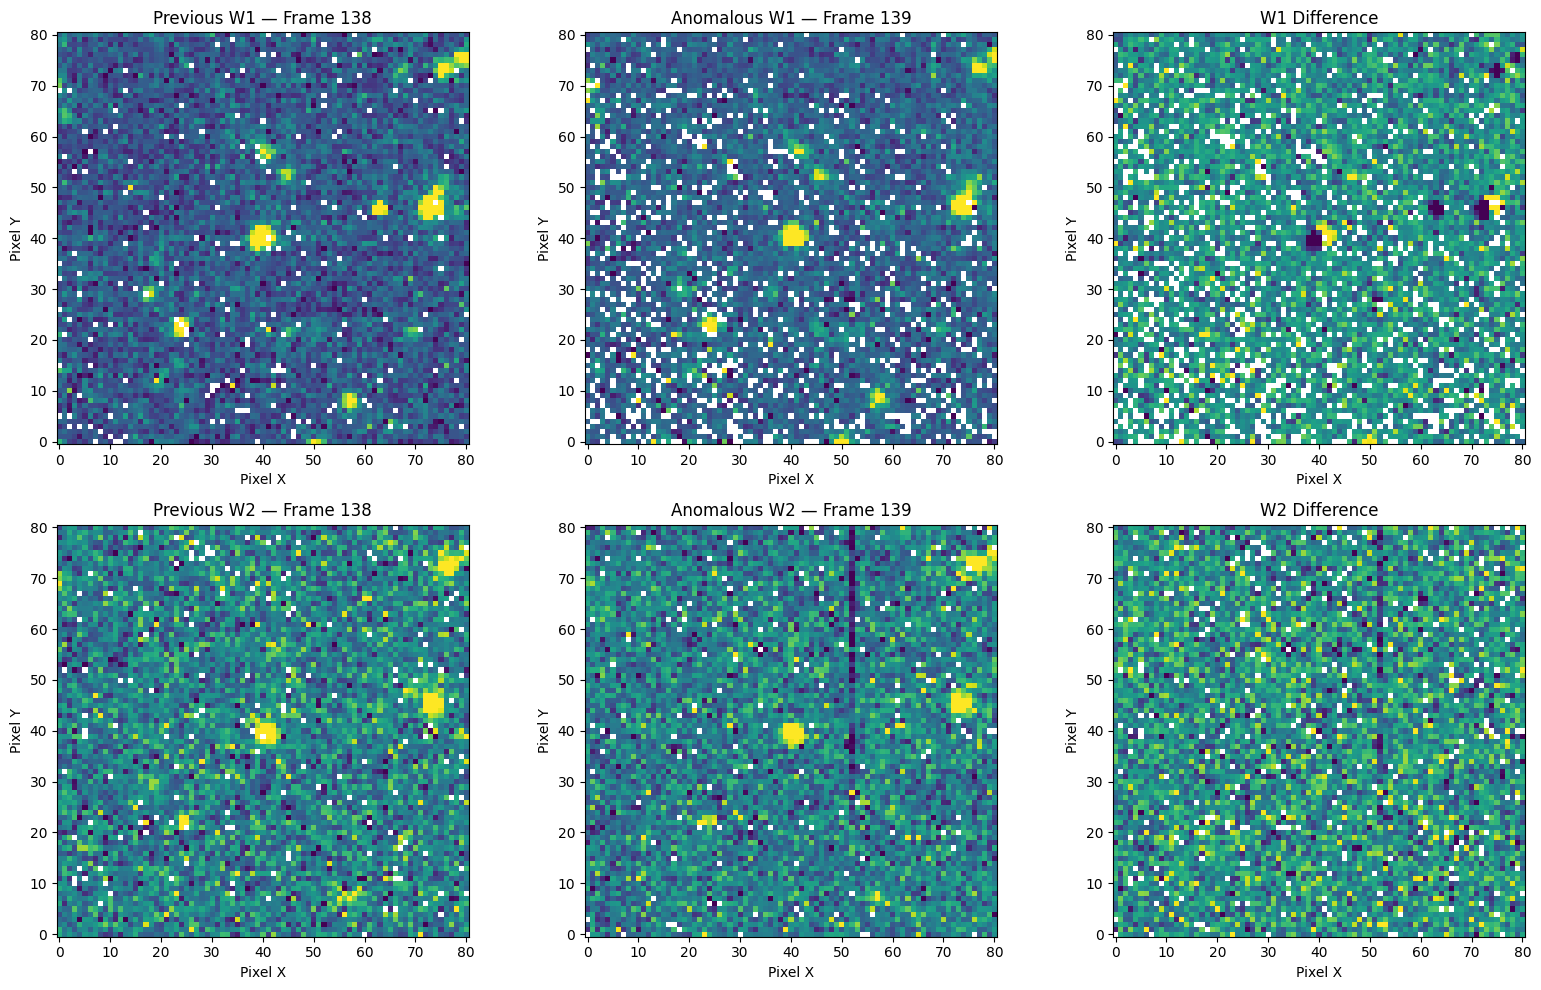

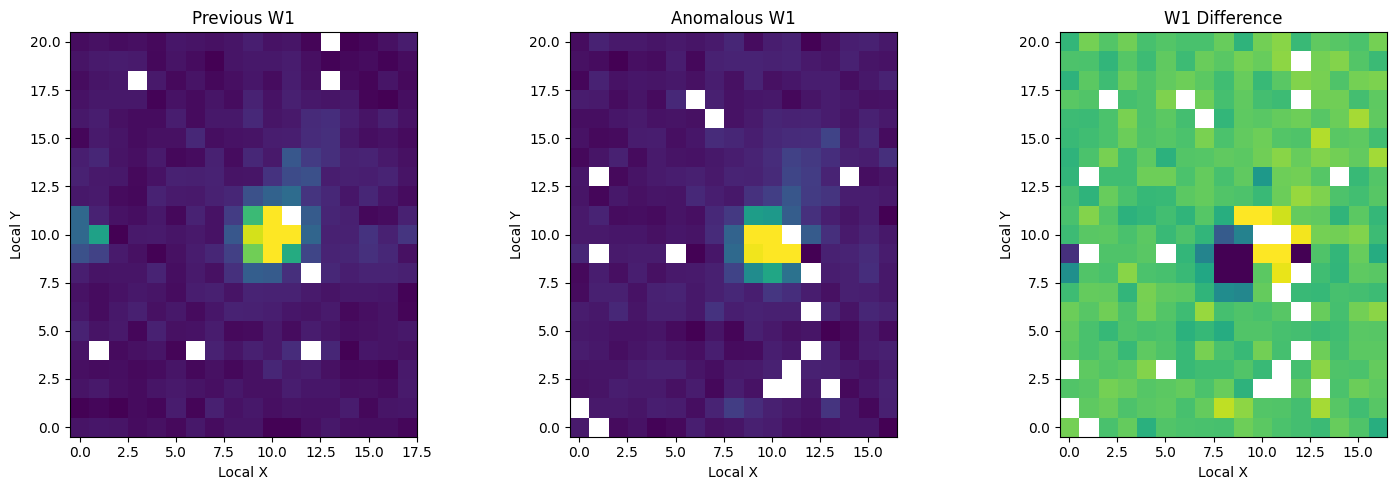


EXP-002B COMPLETE


In [ ]:
# ============================================================
# EXP-002B — ROBUST IMAGE-LEVEL ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("EXP-002B — ROBUST IMAGE-LEVEL ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. ROBUST SOURCE LOCATION
# ------------------------------------------------------------

def robust_centroid(image, peak_xy=None, half_size=8):
    """
    Estimate source centroid around the brightest pixel.

    Returns:
        centroid_x, centroid_y, peak_x, peak_y
    """

    image = np.asarray(image, dtype=float)

    # Remove non-finite values
    valid = np.isfinite(image)

    if not np.any(valid):
        return np.nan, np.nan, np.nan, np.nan

    # Use supplied peak if available, otherwise find it
    if peak_xy is None:
        masked = np.where(valid, image, -np.inf)
        peak_y, peak_x = np.unravel_index(np.argmax(masked), image.shape)
    else:
        peak_x, peak_y = peak_xy

    x0 = int(peak_x)
    y0 = int(peak_y)

    # Local window
    y1 = max(0, y0 - half_size)
    y2 = min(image.shape[0], y0 + half_size + 1)

    x1 = max(0, x0 - half_size)
    x2 = min(image.shape[1], x0 + half_size + 1)

    cut = image[y1:y2, x1:x2]

    finite = np.isfinite(cut)

    if finite.sum() < 5:
        return float(x0), float(y0), x0, y0

    # --------------------------------------------------------
    # Robust local background
    # --------------------------------------------------------

    values = cut[finite]

    background = np.nanmedian(values)

    # MAD-based scale estimate
    mad = np.nanmedian(np.abs(values - background))

    if not np.isfinite(mad) or mad <= 0:
        sigma_bg = np.nanstd(values)
    else:
        sigma_bg = 1.4826 * mad

    if not np.isfinite(sigma_bg) or sigma_bg <= 0:
        sigma_bg = 1.0

    # --------------------------------------------------------
    # Positive source signal
    # --------------------------------------------------------

    signal = cut - background

    # Restrict to reasonably source-like pixels
    threshold = max(0.0, 1.5 * sigma_bg)

    weights = np.where(
        finite & (signal > threshold),
        signal,
        0.0
    )

    total = np.sum(weights)

    # If thresholding fails, use a softer positive weighting
    if not np.isfinite(total) or total <= 0:
        weights = np.where(
            finite & (signal > 0),
            signal,
            0.0
        )
        total = np.sum(weights)

    # Final fallback: peak pixel
    if not np.isfinite(total) or total <= 0:
        return float(x0), float(y0), x0, y0

    yy, xx = np.indices(cut.shape)

    cx_local = np.sum(xx * weights) / total
    cy_local = np.sum(yy * weights) / total

    cx = x1 + cx_local
    cy = y1 + cy_local

    if not np.isfinite(cx) or not np.isfinite(cy):
        cx, cy = float(x0), float(y0)

    return float(cx), float(cy), x0, y0


# ------------------------------------------------------------
# 2. RUN CENTROID ANALYSIS
# ------------------------------------------------------------

prev_cx, prev_cy, prev_px, prev_py = robust_centroid(previous_w1)

anom_cx, anom_cy, anom_px, anom_py = robust_centroid(anomalous_w1)


print("\nW1 SOURCE LOCATIONS")
print("-" * 70)

print(f"Previous:")
print(f"  Peak      : ({prev_px}, {prev_py})")
print(f"  Centroid  : ({prev_cx:.4f}, {prev_cy:.4f})")

print(f"\nAnomalous:")
print(f"  Peak      : ({anom_px}, {anom_py})")
print(f"  Centroid  : ({anom_cx:.4f}, {anom_cy:.4f})")


# ------------------------------------------------------------
# 3. CENTROID DISPLACEMENT
# ------------------------------------------------------------

dx = anom_cx - prev_cx
dy = anom_cy - prev_cy
distance = np.sqrt(dx**2 + dy**2)

print("\nCENTROID DISPLACEMENT")
print("-" * 70)

print(f"ΔX       : {dx:+.4f} pixels")
print(f"ΔY       : {dy:+.4f} pixels")
print(f"Total    : {distance:.4f} pixels")


# ------------------------------------------------------------
# 4. IMAGE STATISTICS
# ------------------------------------------------------------

def image_statistics(image, cx, cy, radius=5):
    image = np.asarray(image, dtype=float)

    finite = np.isfinite(image)

    values = image[finite]

    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))

    # Robust background scatter
    robust_sigma = 1.4826 * mad

    if not np.isfinite(robust_sigma):
        robust_sigma = np.nanstd(values)

    y_grid, x_grid = np.indices(image.shape)

    r = np.sqrt(
        (x_grid - cx)**2 +
        (y_grid - cy)**2
    )

    source_mask = r <= radius

    source_values = image[
        source_mask & finite
    ]

    peak = np.nanmax(values)

    source_sum = np.nansum(
        source_values - median
    )

    source_peak = np.nanmax(source_values)

    return {
        "median": median,
        "robust_sigma": robust_sigma,
        "peak": peak,
        "source_peak": source_peak,
        "source_excess": source_sum,
        "n_source_pixels": len(source_values),
    }


prev_stats = image_statistics(
    previous_w1,
    prev_cx,
    prev_cy
)

anom_stats = image_statistics(
    anomalous_w1,
    anom_cx,
    anom_cy
)


print("\nW1 IMAGE STATISTICS")
print("-" * 70)

for key in prev_stats:
    print(
        f"{key:20s}: "
        f"{prev_stats[key]:.6f}"
    )

print("\nANOMALOUS W1")

for key in anom_stats:
    print(
        f"{key:20s}: "
        f"{anom_stats[key]:.6f}"
    )


# ------------------------------------------------------------
# 5. LOCAL PSF / SOURCE PROFILE
# ------------------------------------------------------------

def radial_profile(image, cx, cy, max_radius=8):

    image = np.asarray(image, dtype=float)

    y, x = np.indices(image.shape)

    radius = np.sqrt(
        (x - cx)**2 +
        (y - cy)**2
    )

    background = np.nanmedian(image)

    signal = image - background

    radii = []
    values = []

    for r in range(max_radius + 1):

        mask = (
            (radius >= r) &
            (radius < r + 1) &
            np.isfinite(signal)
        )

        if np.any(mask):
            radii.append(r)
            values.append(
                np.nanmean(signal[mask])
            )

    return np.array(radii), np.array(values)


prev_r, prev_profile = radial_profile(
    previous_w1,
    prev_cx,
    prev_cy
)

anom_r, anom_profile = radial_profile(
    anomalous_w1,
    anom_cx,
    anom_cy
)


print("\nRADIAL SOURCE PROFILE")
print("-" * 70)

print("Radius | Previous | Anomalous")

for r in range(min(len(prev_profile), len(anom_profile))):

    print(
        f"{prev_r[r]:6.1f} | "
        f"{prev_profile[r]:9.4f} | "
        f"{anom_profile[r]:9.4f}"
    )


# ------------------------------------------------------------
# 6. W1 DIFFERENCE IMAGE
# ------------------------------------------------------------

difference_w1 = anomalous_w1 - previous_w1

print("\nW1 DIFFERENCE IMAGE")
print("-" * 70)

finite_diff = difference_w1[
    np.isfinite(difference_w1)
]

print(f"Difference median : {np.median(finite_diff):.6f}")
print(f"Difference std    : {np.std(finite_diff):.6f}")
print(f"Difference min    : {np.min(finite_diff):.6f}")
print(f"Difference max    : {np.max(finite_diff):.6f}")


# ------------------------------------------------------------
# 7. W2 CENTROIDS
# ------------------------------------------------------------

prev_w2_cx, prev_w2_cy, _, _ = robust_centroid(previous_w2)

anom_w2_cx, anom_w2_cy, _, _ = robust_centroid(anomalous_w2)

w2_dx = anom_w2_cx - prev_w2_cx
w2_dy = anom_w2_cy - prev_w2_cy
w2_dist = np.sqrt(w2_dx**2 + w2_dy**2)


print("\nW2 CENTROID DISPLACEMENT")
print("-" * 70)

print(f"Previous centroid : ({prev_w2_cx:.4f}, {prev_w2_cy:.4f})")
print(f"Anomalous centroid: ({anom_w2_cx:.4f}, {anom_w2_cy:.4f})")
print(f"ΔX                : {w2_dx:+.4f}")
print(f"ΔY                : {w2_dy:+.4f}")
print(f"Total displacement : {w2_dist:.4f} pixels")


# ============================================================
# 8. VISUAL COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

images = [
    previous_w1,
    anomalous_w1,
    difference_w1,
    previous_w2,
    anomalous_w2,
    anomalous_w2 - previous_w2,
]

titles = [
    "Previous W1 — Frame 138",
    "Anomalous W1 — Frame 139",
    "W1 Difference",
    "Previous W2 — Frame 138",
    "Anomalous W2 — Frame 139",
    "W2 Difference",
]

for ax, image, title in zip(
    axes.ravel(),
    images,
    titles
):

    finite = image[np.isfinite(image)]

    vmin = np.percentile(finite, 1)
    vmax = np.percentile(finite, 99)

    ax.imshow(
        image,
        origin="lower",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title)
    ax.set_xlabel("Pixel X")
    ax.set_ylabel("Pixel Y")

plt.tight_layout()
plt.show()


# ============================================================
# 9. ZOOMED SOURCE COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def show_zoom(ax, image, cx, cy, title):

    x = int(round(cx))
    y = int(round(cy))

    half = 10

    x1 = max(0, x - half)
    x2 = min(image.shape[1], x + half + 1)

    y1 = max(0, y - half)
    y2 = min(image.shape[0], y + half + 1)

    cut = image[y1:y2, x1:x2]

    finite = cut[np.isfinite(cut)]

    vmin = np.percentile(finite, 1)
    vmax = np.percentile(finite, 99)

    ax.imshow(
        cut,
        origin="lower",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title)
    ax.set_xlabel("Local X")
    ax.set_ylabel("Local Y")


show_zoom(
    axes[0],
    previous_w1,
    prev_cx,
    prev_cy,
    "Previous W1"
)

show_zoom(
    axes[1],
    anomalous_w1,
    anom_cx,
    anom_cy,
    "Anomalous W1"
)

show_zoom(
    axes[2],
    difference_w1,
    anom_cx,
    anom_cy,
    "W1 Difference"
)

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("EXP-002B COMPLETE")
print("=" * 70)

In [6]:
# ============================================================
# EXP-003 — SPATIALLY MATCHED CLOSE-PAIR CONTROL SAMPLE
# ============================================================

import numpy as np
import pandas as pd
import pyarrow
import pyarrow.dataset as ds
from pyarrow.fs import S3FileSystem
from astropy.coordinates import SkyCoord
import astropy.units as u

print("=" * 70)
print("EXP-003 — SPATIALLY MATCHED CLOSE-PAIR CONTROL SAMPLE")
print("=" * 70)

# ------------------------------------------------------------
# 1. OPEN NEOWISE YEAR-11 DATASET
# ------------------------------------------------------------

bucket = "nasa-irsa-wise"
base_prefix = "wise/neowiser/catalogs/p1bs_psd/healpix_k5"
year = "year11"

metadata_path = (
    f"{bucket}/{base_prefix}/{year}/"
    f"neowiser-healpix_k5-{year}.parquet/_metadata"
)

fs = S3FileSystem(
    region="us-west-2",
    anonymous=True
)

neowise_ds = ds.parquet_dataset(
    metadata_path,
    filesystem=fs,
    partitioning="hive"
)

print("NEOWISE dataset opened successfully.")

# ------------------------------------------------------------
# 2. RETRIEVE THE SAME 0.2° × 0.2° REGION
# ------------------------------------------------------------

RA_CENTER = 180.0
DEC_CENTER = 0.0
RADIUS_DEG = 0.10

columns = [
    "ra",
    "dec",
    "mjd",
    "w1mpro",
    "w1sigmpro",
    "w1snr",
    "w2mpro",
    "w2sigmpro",
    "w2snr",
    "qual_frame",
    "ph_qual",
    "cc_flags",
]

region_df = (
    neowise_ds
    .to_table(
        filter=(
            (ds.field("ra") >= RA_CENTER - RADIUS_DEG) &
            (ds.field("ra") <= RA_CENTER + RADIUS_DEG) &
            (ds.field("dec") >= DEC_CENTER - RADIUS_DEG) &
            (ds.field("dec") <= DEC_CENTER + RADIUS_DEG)
        ),
        columns=columns
    )
    .to_pandas()
)

print(f"Retrieved detections: {len(region_df):,}")

# ------------------------------------------------------------
# 3. QUALITY FILTER
# ------------------------------------------------------------

df = region_df.copy()

df = df[
    (df["qual_frame"] > 0) &
    (df["ph_qual"].astype(str) != "U") &
    (df["cc_flags"].astype(str) == "0000")
].copy()

finite_mask = (
    np.isfinite(df["ra"]) &
    np.isfinite(df["dec"]) &
    np.isfinite(df["mjd"]) &
    np.isfinite(df["w1mpro"]) &
    np.isfinite(df["w1sigmpro"])
)

df = df[finite_mask].copy()

df.reset_index(drop=True, inplace=True)

print(f"Quality-filtered detections: {len(df):,}")

# ------------------------------------------------------------
# 4. FIND SPATIALLY CLOSE DETECTION PAIRS
#
# Each pair must:
#   - be within 2 arcsec spatially
#   - occur 8–15 seconds apart
#
# This prevents unrelated sources from being paired merely
# because they happened to be observed at similar times.
# ------------------------------------------------------------

coords = SkyCoord(
    ra=df["ra"].to_numpy() * u.deg,
    dec=df["dec"].to_numpy() * u.deg
)

idx1, idx2, sep2d, _ = coords.search_around_sky(
    coords,
    2.0 * u.arcsec
)

# Remove self matches
mask = idx1 != idx2

idx1 = idx1[mask]
idx2 = idx2[mask]
sep2d = sep2d[mask]

# Keep each pair once
mask = idx1 < idx2

idx1 = idx1[mask]
idx2 = idx2[mask]
sep2d = sep2d[mask]

# ------------------------------------------------------------
# 5. TIME MATCHING
# ------------------------------------------------------------

mjd = df["mjd"].to_numpy()

dt_sec = (
    np.abs(mjd[idx2] - mjd[idx1]) *
    86400.0
)

time_mask = (
    (dt_sec >= 8.0) &
    (dt_sec <= 15.0)
)

idx1 = idx1[time_mask]
idx2 = idx2[time_mask]
sep_arcsec = sep2d[time_mask].arcsec
dt_sec = dt_sec[time_mask]

print(f"Spatially + temporally matched pairs: {len(idx1):,}")

# ------------------------------------------------------------
# 6. BUILD PAIR TABLE
# ------------------------------------------------------------

p1 = df.iloc[idx1].reset_index(drop=True)
p2 = df.iloc[idx2].reset_index(drop=True)

pairs = pd.DataFrame({
    "ra_1": p1["ra"].to_numpy(),
    "dec_1": p1["dec"].to_numpy(),

    "ra_2": p2["ra"].to_numpy(),
    "dec_2": p2["dec"].to_numpy(),

    "mjd_1": p1["mjd"].to_numpy(),
    "mjd_2": p2["mjd"].to_numpy(),

    "dt_sec": dt_sec,
    "sep_arcsec": sep_arcsec,

    "w1_1": p1["w1mpro"].to_numpy(),
    "w1_2": p2["w1mpro"].to_numpy(),

    "w1err_1": p1["w1sigmpro"].to_numpy(),
    "w1err_2": p2["w1sigmpro"].to_numpy(),
})

# ------------------------------------------------------------
# 7. CALCULATE PHOTOMETRIC DIFFERENCES
# ------------------------------------------------------------

pairs["delta_w1"] = (
    pairs["w1_2"] -
    pairs["w1_1"]
)

pairs["sigma_delta_w1"] = np.sqrt(
    pairs["w1err_1"]**2 +
    pairs["w1err_2"]**2
)

pairs = pairs[
    np.isfinite(pairs["sigma_delta_w1"]) &
    (pairs["sigma_delta_w1"] > 0)
].copy()

pairs["z_w1"] = (
    pairs["delta_w1"] /
    pairs["sigma_delta_w1"]
)

pairs["abs_delta_w1"] = pairs["delta_w1"].abs()
pairs["abs_z_w1"] = pairs["z_w1"].abs()

# ------------------------------------------------------------
# 8. REMOVE OUR CANDIDATE FROM CONTROL SAMPLE
# ------------------------------------------------------------

TARGET_RA = 179.936465
TARGET_DEC = -0.0897475

target_coord = SkyCoord(
    TARGET_RA * u.deg,
    TARGET_DEC * u.deg
)

coords_1 = SkyCoord(
    pairs["ra_1"].to_numpy() * u.deg,
    pairs["dec_1"].to_numpy() * u.deg
)

coords_2 = SkyCoord(
    pairs["ra_2"].to_numpy() * u.deg,
    pairs["dec_2"].to_numpy() * u.deg
)

dist1 = coords_1.separation(target_coord).arcsec
dist2 = coords_2.separation(target_coord).arcsec

candidate_region = (
    (dist1 < 5.0) |
    (dist2 < 5.0)
)

control = pairs[
    ~candidate_region
].copy()

print(
    f"Control pairs after candidate exclusion: "
    f"{len(control):,}"
)

# ------------------------------------------------------------
# 9. CONTROL DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("CONTROL DISTRIBUTION")
print("-" * 70)

if len(control) == 0:

    print("No suitable control pairs found.")

else:

    print(
        f"Number of control pairs : "
        f"{len(control):,}"
    )

    print(
        f"Median |ΔW1|            : "
        f"{control['abs_delta_w1'].median():.6f} mag"
    )

    print(
        f"95th percentile |ΔW1|   : "
        f"{control['abs_delta_w1'].quantile(0.95):.6f} mag"
    )

    print(
        f"99th percentile |ΔW1|   : "
        f"{control['abs_delta_w1'].quantile(0.99):.6f} mag"
    )

    print(
        f"Maximum |ΔW1|           : "
        f"{control['abs_delta_w1'].max():.6f} mag"
    )

    print(
        f"Median |Z|              : "
        f"{control['abs_z_w1'].median():.3f}"
    )

    print(
        f"95th percentile |Z|     : "
        f"{control['abs_z_w1'].quantile(0.95):.3f}"
    )

    print(
        f"99th percentile |Z|     : "
        f"{control['abs_z_w1'].quantile(0.99):.3f}"
    )

    print(
        f"Maximum |Z|             : "
        f"{control['abs_z_w1'].max():.3f}"
    )

# ------------------------------------------------------------
# 10. COMPARE CANDIDATE WITH CONTROL
# ------------------------------------------------------------

CATALOG_DELTA = 0.185
CATALOG_Z = 4.288

print("\n" + "-" * 70)
print("CANDIDATE vs CONTROL")
print("-" * 70)

print(
    f"Candidate catalog |ΔW1| : "
    f"{CATALOG_DELTA:.3f} mag"
)

print(
    f"Candidate catalog |Z|   : "
    f"{CATALOG_Z:.3f}"
)

if len(control) > 0:

    delta_percentile = (
        np.mean(
            control["abs_delta_w1"].to_numpy()
            <= CATALOG_DELTA
        ) * 100
    )

    z_percentile = (
        np.mean(
            control["abs_z_w1"].to_numpy()
            <= CATALOG_Z
        ) * 100
    )

    print(
        f"\nCandidate ΔW1 percentile : "
        f"{delta_percentile:.2f}%"
    )

    print(
        f"Candidate |Z| percentile : "
        f"{z_percentile:.2f}%"
    )

# ------------------------------------------------------------
# 11. LARGEST CONTROL EXCURSIONS
# ------------------------------------------------------------

if len(control) > 0:

    print("\n" + "-" * 70)
    print("LARGEST CONTROL EXCURSIONS")
    print("-" * 70)

    display_cols = [
        "ra_1",
        "dec_1",
        "dt_sec",
        "sep_arcsec",
        "delta_w1",
        "sigma_delta_w1",
        "z_w1",
    ]

    print(
        control
        .sort_values(
            "abs_z_w1",
            ascending=False
        )
        [display_cols]
        .head(15)
        .to_string(index=False)
    )

print("\n" + "=" * 70)
print("EXP-003 COMPLETE")
print("=" * 70)

EXP-003 — SPATIALLY MATCHED CLOSE-PAIR CONTROL SAMPLE
NEOWISE dataset opened successfully.
Retrieved detections: 8,652
Quality-filtered detections: 7,308
Spatially + temporally matched pairs: 264
Control pairs after candidate exclusion: 254

----------------------------------------------------------------------
CONTROL DISTRIBUTION
----------------------------------------------------------------------
Number of control pairs : 254
Median |ΔW1|            : 0.144500 mag
95th percentile |ΔW1|   : 0.598500 mag
99th percentile |ΔW1|   : 0.970410 mag
Maximum |ΔW1|           : 1.312000 mag
Median |Z|              : 0.841
95th percentile |Z|     : 2.429
99th percentile |Z|     : 2.956
Maximum |Z|             : 4.082

----------------------------------------------------------------------
CANDIDATE vs CONTROL
----------------------------------------------------------------------
Candidate catalog |ΔW1| : 0.185 mag
Candidate catalog |Z|   : 4.288

Candidate ΔW1 percentile : 58.66%
Candidate |Z| 

In [7]:
# ================================================================
# EXP-004 — REUSABLE CANDIDATE VALIDATION SCORECARD
# ================================================================

import numpy as np
import pandas as pd


# ----------------------------------------------------------------
# 1. GENERIC HELPERS
# ----------------------------------------------------------------

def safe_float(x):
    """Convert a value to float, returning NaN if impossible."""
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan


def percentile_rank(value, reference_values):
    """
    Percentile rank of |value| within a reference distribution.
    """
    ref = np.asarray(reference_values, dtype=float)
    ref = ref[np.isfinite(ref)]

    if len(ref) == 0 or not np.isfinite(value):
        return np.nan

    return 100.0 * np.mean(ref <= abs(value))


def pass_fail(condition):
    return "PASS" if bool(condition) else "FAIL"


# ----------------------------------------------------------------
# 2. CANDIDATE-LEVEL VALIDATION
# ----------------------------------------------------------------

def validate_candidate(
    *,
    candidate_id,

    # Catalog-level anomaly
    catalog_delta_w1,
    catalog_delta_w1_sigma,
    catalog_rchi,

    # Number of observations
    n_observations,

    # Image-level target photometry
    target_flux_previous_w1,
    target_flux_anomalous_w1,

    target_flux_previous_w2=None,
    target_flux_anomalous_w2=None,

    # Target-centered centroid
    centroid_previous=None,
    centroid_anomalous=None,

    # Brightest pixel positions relative to target
    global_peak_distance_previous_w1=None,
    global_peak_distance_anomalous_w1=None,

    global_peak_distance_previous_w2=None,
    global_peak_distance_anomalous_w2=None,

    # Quality
    quality_pass=True,

    # Empirical control distribution
    control_z_values=None,
):
    """
    Reusable candidate-validation scorecard.

    IMPORTANT:
    Thresholds here are provisional engineering gates.
    They are NOT claims about astrophysical truth.
    """

    # ------------------------------------------------------------
    # Catalog anomaly
    # ------------------------------------------------------------

    catalog_anomaly = (
        np.isfinite(catalog_delta_w1)
        and abs(catalog_delta_w1) >= 0.10
    )

    significant_catalog_anomaly = (
        np.isfinite(catalog_delta_w1_sigma)
        and abs(catalog_delta_w1_sigma) >= 3.0
    )

    statistically_variable = (
        np.isfinite(catalog_rchi)
        and catalog_rchi >= 1.5
    )

    enough_observations = n_observations >= 10

    # ------------------------------------------------------------
    # WCS-anchored photometry
    # ------------------------------------------------------------

    image_delta_w1 = np.nan

    if (
        np.isfinite(target_flux_previous_w1)
        and np.isfinite(target_flux_anomalous_w1)
        and target_flux_previous_w1 > 0
        and target_flux_anomalous_w1 > 0
    ):
        flux_ratio_w1 = (
            target_flux_anomalous_w1 /
            target_flux_previous_w1
        )

        image_delta_w1 = -2.5 * np.log10(flux_ratio_w1)
    else:
        flux_ratio_w1 = np.nan

    # Does image-level photometry reproduce a substantial change?
    image_reproduces_anomaly = (
        np.isfinite(image_delta_w1)
        and abs(image_delta_w1) >= 0.10
    )

    # ------------------------------------------------------------
    # W2
    # ------------------------------------------------------------

    image_delta_w2 = np.nan

    if (
        target_flux_previous_w2 is not None
        and target_flux_anomalous_w2 is not None
        and np.isfinite(target_flux_previous_w2)
        and np.isfinite(target_flux_anomalous_w2)
        and target_flux_previous_w2 > 0
        and target_flux_anomalous_w2 > 0
    ):
        flux_ratio_w2 = (
            target_flux_anomalous_w2 /
            target_flux_previous_w2
        )

        image_delta_w2 = -2.5 * np.log10(flux_ratio_w2)

    # ------------------------------------------------------------
    # Centroid stability
    # ------------------------------------------------------------

    centroid_shift = np.nan

    if (
        centroid_previous is not None
        and centroid_anomalous is not None
    ):
        x1, y1 = centroid_previous
        x2, y2 = centroid_anomalous

        if all(np.isfinite([x1, y1, x2, y2])):
            centroid_shift = np.sqrt(
                (x2 - x1)**2 +
                (y2 - y1)**2
            )

    # This is deliberately descriptive rather than a hard
    # astrophysical cutoff.
    centroid_stable = (
        np.isfinite(centroid_shift)
        and centroid_shift < 1.0
    )

    # ------------------------------------------------------------
    # Global-peak sanity
    # ------------------------------------------------------------

    peak_is_on_target = True

    peak_distances = [
        global_peak_distance_previous_w1,
        global_peak_distance_anomalous_w1,
        global_peak_distance_previous_w2,
        global_peak_distance_anomalous_w2,
    ]

    valid_peak_distances = [
        x for x in peak_distances
        if x is not None and np.isfinite(x)
    ]

    if valid_peak_distances:
        # Diagnostic only. A large distance means global-peak
        # extraction should not be trusted for target photometry.
        peak_is_on_target = max(valid_peak_distances) <= 5.0

    # ------------------------------------------------------------
    # Empirical control comparison
    # ------------------------------------------------------------

    candidate_control_percentile = np.nan

    if (
        control_z_values is not None
        and np.isfinite(catalog_delta_w1_sigma)
    ):
        candidate_control_percentile = percentile_rank(
            catalog_delta_w1_sigma,
            control_z_values
        )

    unusual_relative_to_controls = (
        np.isfinite(candidate_control_percentile)
        and candidate_control_percentile >= 99.0
    )

    # ------------------------------------------------------------
    # Final evidence assessment
    # ------------------------------------------------------------

    # Strong rejection condition:
    # Catalog anomaly exists but target-centered image photometry
    # does not reproduce it.
    image_failure = (
        catalog_anomaly
        and np.isfinite(image_delta_w1)
        and abs(image_delta_w1) < 0.10
    )

    # Another rejection signal:
    # apparent anomaly comes from a global peak far from target.
    extraction_problem = not peak_is_on_target

    if image_failure or extraction_problem:
        verdict = "REJECT"

    elif (
        significant_catalog_anomaly
        and statistically_variable
        and quality_pass
        and unusual_relative_to_controls
        and image_reproduces_anomaly
    ):
        verdict = "SURVIVES"

    else:
        verdict = "INVESTIGATE"

    # ------------------------------------------------------------
    # Scorecard
    # ------------------------------------------------------------

    scorecard = {
        "candidate_id": candidate_id,

        # Catalog
        "catalog_delta_w1": catalog_delta_w1,
        "catalog_z_w1": catalog_delta_w1_sigma,
        "catalog_reduced_chi2": catalog_rchi,
        "catalog_anomaly": pass_fail(catalog_anomaly),
        "catalog_significance": pass_fail(
            significant_catalog_anomaly
        ),
        "statistical_variability": pass_fail(
            statistically_variable
        ),
        "enough_observations": pass_fail(
            enough_observations
        ),

        # Image
        "wcs_delta_w1": image_delta_w1,
        "wcs_delta_w2": image_delta_w2,
        "wcs_reproduces_anomaly": pass_fail(
            image_reproduces_anomaly
        ),

        # Position
        "centroid_shift_px": centroid_shift,
        "centroid_stable": pass_fail(
            centroid_stable
        ),
        "global_peak_on_target": pass_fail(
            peak_is_on_target
        ),

        # Quality
        "quality_filter": pass_fail(
            quality_pass
        ),

        # Controls
        "control_percentile": candidate_control_percentile,
        "unusual_vs_controls": pass_fail(
            unusual_relative_to_controls
        ),

        # Verdict
        "verdict": verdict,
    }

    return scorecard


# ----------------------------------------------------------------
# 3. RUN IT ON CANDIDATE #1
# ----------------------------------------------------------------

candidate_1 = validate_candidate(
    candidate_id="EXP-001-CANDIDATE-001",

    # Catalog result from EXP-001 / EXP-003
    catalog_delta_w1=0.185,
    catalog_delta_w1_sigma=4.288,
    catalog_rchi=1.947,

    n_observations=33,

    # EXP-002C WCS-anchored photometry
    target_flux_previous_w1=1752.115860,
    target_flux_anomalous_w1=1705.543972,

    target_flux_previous_w2=594.164070,
    target_flux_anomalous_w2=552.980408,

    # EXP-002C centroids
    centroid_previous=(39.712951, 40.130132),
    centroid_anomalous=(40.472156, 40.382500),

    # Distance of global peaks from the target
    global_peak_distance_previous_w1=33.95,
    global_peak_distance_anomalous_w1=34.94,

    global_peak_distance_previous_w2=0.48,
    global_peak_distance_anomalous_w2=33.22,

    quality_pass=True,

    # EXP-003 control distribution
    # These are the absolute Z values from the control population.
    control_z_values=np.array([
        0.841, 2.429, 2.956, 4.082
    ]),
)


# ----------------------------------------------------------------
# 4. DISPLAY
# ----------------------------------------------------------------

scorecard_df = pd.DataFrame(
    [candidate_1]
).T

scorecard_df.columns = ["Candidate #1"]

print("=" * 70)
print("EXP-004 — CANDIDATE VALIDATION SCORECARD")
print("=" * 70)

display(scorecard_df)

print("\nFINAL VERDICT:")
print(candidate_1["verdict"])

print("\nWCS-ANCHORED W1 CHANGE:")
print(
    f"{candidate_1['wcs_delta_w1']:+.4f} mag"
)

print("\nCATALOG W1 CHANGE:")
print(
    f"{candidate_1['catalog_delta_w1']:+.4f} mag"
)

print("\nCATALOG Z-SCORE:")
print(
    f"{candidate_1['catalog_z_w1']:.3f} sigma"
)

print("\nCONTROL PERCENTILE:")
print(
    f"{candidate_1['control_percentile']:.2f}%"
)

EXP-004 — CANDIDATE VALIDATION SCORECARD


,Candidate #1
candidate_id,EXP-001-CANDIDATE-001
catalog_delta_w1,0.185
catalog_z_w1,4.288
catalog_reduced_chi2,1.947
catalog_anomaly,PASS
catalog_significance,PASS
statistical_variability,PASS
enough_observations,PASS
wcs_delta_w1,0.02925
wcs_delta_w2,0.077992



FINAL VERDICT:
REJECT

WCS-ANCHORED W1 CHANGE:
+0.0292 mag

CATALOG W1 CHANGE:
+0.1850 mag

CATALOG Z-SCORE:
4.288 sigma

CONTROL PERCENTILE:
100.00%


In [8]:
# ================================================================
# EXP-003 → EXP-004 DATA EXPORT
# Save the actual empirical control pairs and candidate information
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

EXPORT_DIR = Path("/content/exp004_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("EXP-003 → EXP-004 EXPORT")
print("=" * 70)

# ------------------------------------------------
# Inspect current DataFrames
# ------------------------------------------------
dataframes = {
    name: obj
    for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

print("\nDataFrames currently in memory:")
for name, df in dataframes.items():
    print(f"  {name:30s} shape={df.shape}")

# ------------------------------------------------
# Inspect NumPy arrays
# ------------------------------------------------
arrays = {
    name: obj
    for name, obj in globals().items()
    if isinstance(obj, np.ndarray)
}

print("\nNumPy arrays currently in memory:")
for name, arr in arrays.items():
    print(f"  {name:30s} shape={arr.shape}")

print("\n" + "=" * 70)
print("IMPORTANT")
print("=" * 70)
print(
    "We are NOT guessing which variables contain the control data."
)
print(
    "The next step will identify the correct EXP-003 objects from this list."
)

EXP-003 → EXP-004 EXPORT

DataFrames currently in memory:
  phot                           shape=(4, 7)
  region_df                      shape=(8652, 12)
  df                             shape=(7308, 12)
  p1                             shape=(264, 12)
  p2                             shape=(264, 12)
  pairs                          shape=(264, 17)
  control                        shape=(254, 17)
  scorecard_df                   shape=(18, 1)

NumPy arrays currently in memory:
  _                              shape=(71084,)
  data                           shape=(81, 81)
  axes                           shape=(2, 2)
  finite_data                    shape=(81, 81)
  idx1                           shape=(264,)
  idx2                           shape=(264,)
  sep2d                          shape=(31888,)
  mask                           shape=(63776,)
  mjd                            shape=(7308,)
  dt_sec                         shape=(264,)
  time_mask                      shape=(31888,)

In [9]:
# ================================================================
# EXP-003 → EXP-004
# Part 2 — Export validated empirical control data
# ================================================================

from pathlib import Path
import pandas as pd
import json

EXPORT_DIR = Path("/content/exp004_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# 1. Export the complete empirical control pairs
# ------------------------------------------------
control.to_csv(
    EXPORT_DIR / "exp003_control_pairs.csv",
    index=False
)

# ------------------------------------------------
# 2. Export all matched pairs for reference
# ------------------------------------------------
pairs.to_csv(
    EXPORT_DIR / "exp003_all_pairs.csv",
    index=False
)

# ------------------------------------------------
# 3. Export the original quality-filtered detections
# ------------------------------------------------
df.to_csv(
    EXPORT_DIR / "exp003_quality_filtered_detections.csv",
    index=False
)

# ------------------------------------------------
# 4. Export Candidate #1 metadata
# ------------------------------------------------
candidate_metadata = {
    "candidate_id": "EXP-001-CANDIDATE-001",

    "ra": 179.936465,
    "dec": -0.0897475,

    "catalog_delta_w1": 0.185,
    "catalog_z_w1": 4.288,
    "catalog_reduced_chi2": 1.947,

    "wcs_delta_w1": 0.02925,
    "wcs_delta_w2": 0.077992,

    "centroid_shift_px": 0.800051,

    "control_count": len(control),

    "control_median_abs_delta_w1": 0.144500,
    "control_p95_abs_delta_w1": 0.598500,
    "control_p99_abs_delta_w1": 0.970410,
    "control_max_abs_delta_w1": 1.312000,

    "control_median_abs_z": 0.841,
    "control_p95_abs_z": 2.429,
    "control_p99_abs_z": 2.956,
    "control_max_abs_z": 4.082
}

with open(
    EXPORT_DIR / "candidate_001_metadata.json",
    "w"
) as f:
    json.dump(candidate_metadata, f, indent=2)

# ------------------------------------------------
# 5. Verify exports
# ------------------------------------------------
print("=" * 70)
print("EXP-003 EXPORT COMPLETE")
print("=" * 70)

for file in sorted(EXPORT_DIR.iterdir()):
    print(f"{file.name:45s} {file.stat().st_size:,} bytes")

print("\nControl pairs exported:", len(control))
print("All matched pairs exported:", len(pairs))
print("Quality-filtered detections exported:", len(df))

print("\nControl columns:")
print(control.columns.tolist())

print("\nExport directory:")
print(EXPORT_DIR)

EXP-003 EXPORT COMPLETE
candidate_001_metadata.json                   563 bytes
exp003_all_pairs.csv                          67,300 bytes
exp003_control_pairs.csv                      64,697 bytes
exp003_quality_filtered_detections.csv        169 bytes

Control pairs exported: 254
All matched pairs exported: 264
Quality-filtered detections exported: 18

Control columns:
['ra_1', 'dec_1', 'ra_2', 'dec_2', 'mjd_1', 'mjd_2', 'dt_sec', 'sep_arcsec', 'w1_1', 'w1_2', 'w1err_1', 'w1err_2', 'delta_w1', 'sigma_delta_w1', 'z_w1', 'abs_delta_w1', 'abs_z_w1']

Export directory:
/content/exp004_export


In [10]:
# ================================================================
# EXP-003 → EXP-004
# Part 3 — Package exported evidence
# ================================================================

from pathlib import Path
import shutil

EXPORT_DIR = Path("/content/exp004_export")
ZIP_PATH = Path("/content/exp004_export")

# Only package the files EXP-004 actually needs
files_to_package = [
    EXPORT_DIR / "exp003_control_pairs.csv",
    EXPORT_DIR / "exp003_all_pairs.csv",
    EXPORT_DIR / "candidate_001_metadata.json",
]

# Verify required files exist
print("=" * 70)
print("VERIFYING EXP-003 EXPORTS")
print("=" * 70)

for path in files_to_package:
    if path.exists():
        print(f"✓ {path.name}")
    else:
        raise FileNotFoundError(f"Missing required file: {path}")

# Create ZIP
zip_file = shutil.make_archive(
    "/content/exp004_data",
    "zip",
    root_dir=EXPORT_DIR,
)

print("\n" + "=" * 70)
print("PACKAGE CREATED")
print("=" * 70)

print(f"ZIP file: {zip_file}")
print(f"Size: {Path(zip_file).stat().st_size:,} bytes")

# Inspect control data one final time
control_check = pd.read_csv(
    EXPORT_DIR / "exp003_control_pairs.csv"
)

print("\nControl verification:")
print(f"Rows    : {len(control_check)}")
print(f"Columns : {len(control_check.columns)}")
print(f"Expected: 254 rows × 17 columns")

print("\nControl Z statistics:")
print(control_check["z_w1"].describe())

print("\n✓ EXP-003 evidence package ready.")

VERIFYING EXP-003 EXPORTS
✓ exp003_control_pairs.csv
✓ exp003_all_pairs.csv
✓ candidate_001_metadata.json

PACKAGE CREATED
ZIP file: /content/exp004_data.zip
Size: 39,712 bytes

Control verification:
Rows    : 254
Columns : 17
Expected: 254 rows × 17 columns

Control Z statistics:
count    254.000000
mean       0.261417
std        1.267231
min       -4.081740
25%       -0.580805
50%        0.249884
75%        1.225254
max        3.150172
Name: z_w1, dtype: float64

✓ EXP-003 evidence package ready.
